# EnergyScope Results Analysis - BNA

**EnergyScope MultiCell** optimisation of the *BNA* region (Bolivia), represented by **5 clustered cells** (C1-C5) that preserve differences in grid connectivity, population density and existing infrastructure.

**Research question**: *how should this isolated region plan its energy transition under different demand and transition scenarios?*

This notebook analyses **one scenario** in detail (`SCENARIO`, defined below), then compares in section 10 **universal sufficiency** (reference) against **current system**, **supply transition** (centralised grid reinforcement) and **universal access** (decentralised access via home systems + grid extension), and produces in sections 11 and 12 the fourteen figures of thesis chapter 5.

## Plan
1. Executive summary - corrected indicators
2. **End-use demand** - what drives the system
3. **Autonomy & imports** - external dependence by region
4. Carbon footprint (GWP) + intensity
5. Storage
6. Curtailment & flexibility
7. Inter-regional exchanges
8. Hourly profiles - electric dispatch vs demand
9. Synthesis
10. **Scenario comparison** - universal sufficiency vs current system vs supply transition vs universal access
11. **Chapter 5 figures** - supply mix, costs, hot water, access comparison, off-grid match, cost waterfall, scenario comparison, cost-emissions trade-off, hot-water sensitivity

Manuscript figures produced here: **15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 29, 33, 35**.
Every other section is a complementary analysis and is labelled as such.

---
**Units**: costs in M€/year . energy in GWh/year . capacity in GW . GWP in kt CO2-eq/year


In [1]:
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_theme(style='whitegrid')

In [2]:
def find_repo_root():
    """Repository root, whether this notebook runs from scripts/ or from the root."""
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate / 'esmc').is_dir() and (candidate / 'case_studies').is_dir():
            return candidate
    raise RuntimeError(f'repository root not found above {here}')


ES_ROOT = find_repo_root()
for p in (str(ES_ROOT), str(ES_ROOT / 'scripts')):
    if p not in sys.path:
        sys.path.insert(0, p)
from paths import BOLIVIA_DATA
from colors import TECH_COLORS, EUD_COLORS

ROOT = ES_ROOT / 'case_studies' / 'C1_C2_C3_C4_C5'
DATA = ES_ROOT / 'Data' / '2025'   # inputs are now split per demand scenario: sufficiency/ and reality/

SCENARIO = 'norte_amazonia_sufficiency_2025'
DATA_DIR = DATA / 'sufficiency'          # input folder matching SCENARIO

BASE   = ROOT / SCENARIO / 'outputs'
REG    = BASE / 'regional_results'

SCEN_REF = 'Universal sufficiency'    # reference against which deltas are computed
COMPARE = {
    'Universal sufficiency': 'norte_amazonia_sufficiency_2025',
    'Current system':        'norte_amazonia_reality_2025',
    'Supply transition':     'norte_amazonia_reality_2025_phase2',
    'Universal access':      'norte_amazonia_reality_access_2025',
    'Access transition':     'norte_amazonia_access_transition_2025',
}
# Scenarios that connect every dispersed household to the grid, hence carry the
# BC grid-extension CAPEX (see section 12.4): Universal sufficiency (full
# regional redesign), Universal access and Access transition (dedicated home
# systems, same spatial classification as Universal access). Supply
# transition only reinforces the existing centralised grid - it creates no new
# connections, same as Current system -> 0 for both.
GRID_EXT_SCEN = {'Universal sufficiency', 'Universal access', 'Access transition'}
SCEN_COLORS = {'Universal sufficiency': '#E4848F', 'Current system': '#8FC7A8',
               'Supply transition': '#5A9AE3', 'Universal access': '#D9A441',
               'Access transition': '#8B6DAE'}

REGIONS = ['C1', 'C2', 'C3', 'C4', 'C5']
REGION_LABELS = {r: r for r in REGIONS}

EPS = 1e-6   # below this a value counts as zero

# storage technologies, excluded from production mixes
STORAGE_TECHS = {'BATT_LI', 'BATT_HS', 'CAES', 'PHS', 'DAM_STORAGE', 'TS_DEC_HP_ELEC',
                 'TS_HIGH_TEMP', 'GAS_STORAGE', 'H2_STORAGE', 'DIESEL_STORAGE',
                 'LPG_STORAGE', 'GASOLINE_STORAGE', 'JET_FUEL_STORAGE', 'LNG_STORAGE',
                 'AMMONIA_STORAGE', 'METHANOL_STORAGE', 'CO2_STORAGE'}

RENEW_ELEC  = {'PV_UTILITY', 'PV_ROOFTOP', 'PV_HS', 'WIND_ONSHORE', 'WIND_OFFSHORE',
               'HYDRO_DAM', 'HYDRO_RIVER', 'TIDAL_STREAM', 'TIDAL_RANGE', 'WAVE',
               'GEOTHERMAL', 'BIOMASS_TO_POWER', 'ST_BIOMASS', 'ST_SNG'}
FOSSIL_ELEC = {'GENSET_DIESEL', 'HS_DIESEL', 'OCGT', 'CCGT', 'CCGT_AMMONIA',
               'COAL_US', 'COAL_IGCC', 'NUCLEAR', 'NUCLEAR_SMR'}
IMPORT_ELEC = {'ELECTRICITY'}   # the ELECTRICITY resource = import from outside

TECH_LABELS = {
    'PV_UTILITY': 'PV utility', 'PV_ROOFTOP': 'PV rooftop', 'PV_HS': 'PV household',
    'WIND_ONSHORE': 'Onshore wind', 'HYDRO_DAM': 'Hydro dam', 'HYDRO_RIVER': 'Run-of-river hydro',
    'GEOTHERMAL': 'Geothermal', 'BIOMASS_TO_POWER': 'Biomass power',
    'ST_SNG': 'SNG turbine', 'ST_BIOMASS': 'Biomass turbine',
    'GENSET_DIESEL': 'Diesel genset', 'HS_DIESEL': 'Household diesel',
    'OCGT': 'OCGT', 'CCGT': 'CCGT', 'ELECTRICITY': 'Electricity import',
    'BATT_LI': 'Li-ion battery', 'BATT_HS': 'Household battery',
    'DEC_SOLAR': 'Solar water heater', 'DEC_DIRECT_ELEC': 'Direct electric heater',
    'DEC_BOILER_GAS': 'Gas boiler', 'STOVE_LPG': 'LPG stove', 'STOVE_ELEC': 'Electric stove',
    'SIN_IMPORT': 'Grid import (SIN)', 'INTERCLUSTER_IMPORT': 'Inter-cluster import',
    'DEC_ELEC_COLD': 'Air conditioning', 'HVAC_LINE': 'Inter-cluster lines',
    'TS_DEC_DIRECT_ELEC': 'Hot water tank',
}
def get_label(t): return TECH_LABELS.get(t, t)

# cost / GWP category colours, reused in sections 4, 10 and 11
COST_COLORS = {'C_inv': '#5A9AE3', 'C_maint': '#A384E4', 'C_op': '#C2704D'}
COST_LABELS = {'C_inv': 'Investment', 'C_maint': 'Maintenance', 'C_op': 'Operation'}
GWP_COLORS = {'GWP_constr': '#A98ADE', 'GWP_op': '#C2704D'}
GWP_LABELS = {'GWP_constr': 'Construction', 'GWP_op': 'Operation'}
def get_color(t): return TECH_COLORS.get(t, '#B0C4D4')

EUD_LABELS = {
    'COOKING': 'Cooking', 'ELECTRICITY': 'Direct electricity',
    'SPACE_COOLING': 'Space cooling', 'FOOD_PRESERVATION': 'Refrigeration',
    'HEAT_LOW_T_DECEN': 'Low-T heat', 'LIGHTING_R_C': 'Res./com. lighting',
    'LIGHTING_P': 'Public lighting', 'MECHANICAL_ENERGY_COMM': 'Mech. commerce',
    'MECHANICAL_ENERGY_IND': 'Mech. industry',
    'MECHANICAL_ENERGY_FIX_AGR': 'Mech. agriculture',
    'MECHANICAL_ENERGY_FISH_OTHERS': 'Mech. fishing',
}
def eud_label(l): return EUD_LABELS.get(l, l)
def eud_color(l): return EUD_COLORS.get(l, '#B0C4D4')

print(f'main scenario : {SCENARIO}')
print(f'data folder   : {DATA_DIR.relative_to(ES_ROOT)}')
print(f'comparison    : {list(COMPARE)}   (ref = {SCEN_REF})')

main scenario : norte_amazonia_sufficiency_2025
data folder   : Data\2025\sufficiency
comparison    : ['Universal sufficiency', 'Current system', 'Supply transition', 'Universal access', 'Access transition']   (ref = Universal sufficiency)


In [3]:
def num(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce')
    return df

def load_scenario(base):
    reg = base / 'regional_results'
    D = {}
    D['total_cost'] = pd.read_csv(reg / 'TotalCost.csv', sep=';')
    D['assets']     = num(pd.read_csv(reg / 'Assets.csv', sep=';'), ['F', 'F_year'])
    D['cost']       = num(pd.read_csv(reg / 'Cost_breakdown.csv', sep=';'), ['C_inv', 'C_maint', 'C_op'])
    D['gwp']        = num(pd.read_csv(reg / 'Gwp_breakdown.csv', sep=';'), ['GWP_constr', 'GWP_op', 'CO2_net'])
    D['curt']       = num(pd.read_csv(reg / 'Curt.csv', sep=';'), ['Curt'])
    D['sto']        = num(pd.read_csv(reg / 'Sto_assets.csv', sep=';'), ['F', 'Year_energy_flux', 'Losses'])
    D['exch']       = num(pd.read_csv(reg / 'Exchanges_year.csv', sep=';'), ['Exchanges_year', 'Transfer_capacity', 'Utilization_factor'])
    D['res']        = num(pd.read_csv(reg / 'Resources.csv', sep=';'),
                          ['R_year_local', 'R_year_exterior', 'R_year_import', 'R_year_export'])
    D['yb']         = pd.read_csv(reg / 'Year_balance.csv', sep=';')
    D['objective']  = pd.read_csv(base / 'Objective.csv', sep=';')
    D['solve']      = pd.read_csv(base / 'Solve_info.csv', sep=';')
    return D

D = load_scenario(BASE)
total_cost = D['total_cost']; total_cost = total_cost[total_cost['Regions'].isin(REGIONS)].copy()
assets, cost_reg, gwp_reg = D['assets'], D['cost'], D['gwp']
curt_reg, sto_reg, exch_reg, res_reg = D['curt'], D['sto'], D['exch'], D['res']
yb, objective, solve_info = D['yb'], D['objective'], D['solve']

def layer(yb, lay):
    '''Return (Regions, Elements, val) for a given energy layer.'''
    d = yb[['Regions', 'Elements', lay]].copy()
    d[lay] = pd.to_numeric(d[lay], errors='coerce').fillna(0)
    return d.rename(columns={lay: 'val'})

def elec_supply(yb, regions):
    '''Electricity supply mix: positive production values, storage excluded.'''
    d = layer(yb, 'ELECTRICITY')
    d = d[(d['val'] > EPS) & (~d['Elements'].isin(STORAGE_TECHS)) & (d['Regions'].isin(regions))]
    return d

def eud_demand(yb, regions):
    '''Useful demand by end-use and region (positive values, GWh/year).'''
    eu = yb[yb['Elements'] == 'END_USES'].set_index('Regions')
    out = {}
    for lay in EUD_LABELS:
        if lay in eu.columns:
            out[lay] = pd.to_numeric(eu[lay], errors='coerce').abs()
    dem = pd.DataFrame(out).reindex(regions).fillna(0)
    return dem.loc[:, dem.sum() > 1e-4]

print(f"regions      : {sorted(yb['Regions'].unique())}")
print(f"balance rows : {len(yb)}   |   techs/resources : {yb['Elements'].nunique()}")

regions      : ['C1', 'C2', 'C3', 'C4', 'C5']
balance rows : 1520   |   techs/resources : 304


---
## 1. Executive summary

**Corrected** key indicators. Note: unlike a naive sum of `F_year` (which mixes storage, grid and conversion capacities together and has no physical meaning), electricity production and useful demand are here computed from the **annual balance per vector** (`Year_balance`).


In [4]:
obj_value      = float(objective.iloc[0, -1])
solve_time_s   = float(solve_info[solve_info.iloc[:, 0].astype(str).str.contains('solve_elapsed', na=False)].iloc[0, 1])
total_sys_cost = total_cost['TotalCost'].sum()

# Actual electricity production (ELECTRICITY vector, storage excluded)
es = elec_supply(yb, REGIONS)
elec_total   = es['val'].sum()
elec_import  = es[es['Elements'].isin(IMPORT_ELEC)]['val'].sum()
elec_local   = elec_total - elec_import
elec_renew   = es[es['Elements'].isin(RENEW_ELEC)]['val'].sum()

# Total useful demand (all end-uses)
dem = eud_demand(yb, REGIONS)
demande_totale = dem.values.sum()

# Emissions: operational GWP (consistent with section 6 and synthesis)
gwp_op_tot = pd.to_numeric(gwp_reg['GWP_op'], errors='coerce').fillna(0).sum()

# Technologies actually deployed (capacity F > 0)
af = assets[assets['F'] > EPS]
n_active = af['Technologies'].nunique()

print(f'EXECUTIVE SUMMARY - {SCENARIO}')
print(f'  Total system cost             : {total_sys_cost:>9.2f} M€/year')
print(f'  Useful demand served          : {demande_totale:>9.1f} GWh/year')
print(f'  Electricity production        : {elec_total:>9.1f} GWh/year')
print(f'     . local                     : {elec_local:>9.1f} GWh/year ({elec_local/elec_total*100:4.1f} %)')
print(f'     . imported                  : {elec_import:>9.1f} GWh/year ({elec_import/elec_total*100:4.1f} %)')
print(f'     . renewable (local)         : {elec_renew:>9.1f} GWh/year ({elec_renew/elec_total*100:4.1f} %)')
print(f'  Operational GWP emissions     : {gwp_op_tot:>9.2f} kt CO2-eq/year')
print(f'  Average electricity cost      : {total_sys_cost*1000/demande_totale:>9.1f} EUR/MWh utile')
print(f'  Deployed technologies         : {n_active:>9d}')
print(f'  Solver elapsed time           : {solve_time_s:>9.1f} s')
print('  Cost breakdown by region      :')
for _, r in total_cost.sort_values('TotalCost', ascending=False).iterrows():
    pct = r['TotalCost'] / total_sys_cost * 100
    print(f'    {r["Regions"]}  {r["TotalCost"]:>6.2f} M-euro  {pct:4.1f}%')

EXECUTIVE SUMMARY - norte_amazonia_sufficiency_2025
  Total system cost             :     31.28 M€/year
  Useful demand served          :     270.0 GWh/year
  Electricity production        :     158.7 GWh/year
     . local                     :     144.8 GWh/year (91.2 %)
     . imported                  :      13.9 GWh/year ( 8.8 %)
     . renewable (local)         :     142.6 GWh/year (89.9 %)
  Operational GWP emissions     :     47.53 kt CO2-eq/year
  Average electricity cost      :     115.8 EUR/MWh utile
  Deployed technologies         :        37
  Solver elapsed time           :      88.9 s
  Cost breakdown by region      :
    C3   15.84 M-euro  50.6%
    C4    6.58 M-euro  21.0%
    C5    5.85 M-euro  18.7%
    C1    2.68 M-euro   8.6%
    C2    0.33 M-euro   1.1%


---
## 2. End-use demand  [complementary, not in the manuscript]

This is the **starting point** of the thesis: the optimal supply strategy depends directly on the structure of demand. The *useful* demand is read here (the `END_USES` row of the balance), independently of the vector that satisfies it.

> The `sufficiency` vs `reality` comparison reads directly off this chart: same code, different `SCENARIO`. Section 10 produces it for all four scenarios (current system, supply transition, universal access, universal sufficiency).


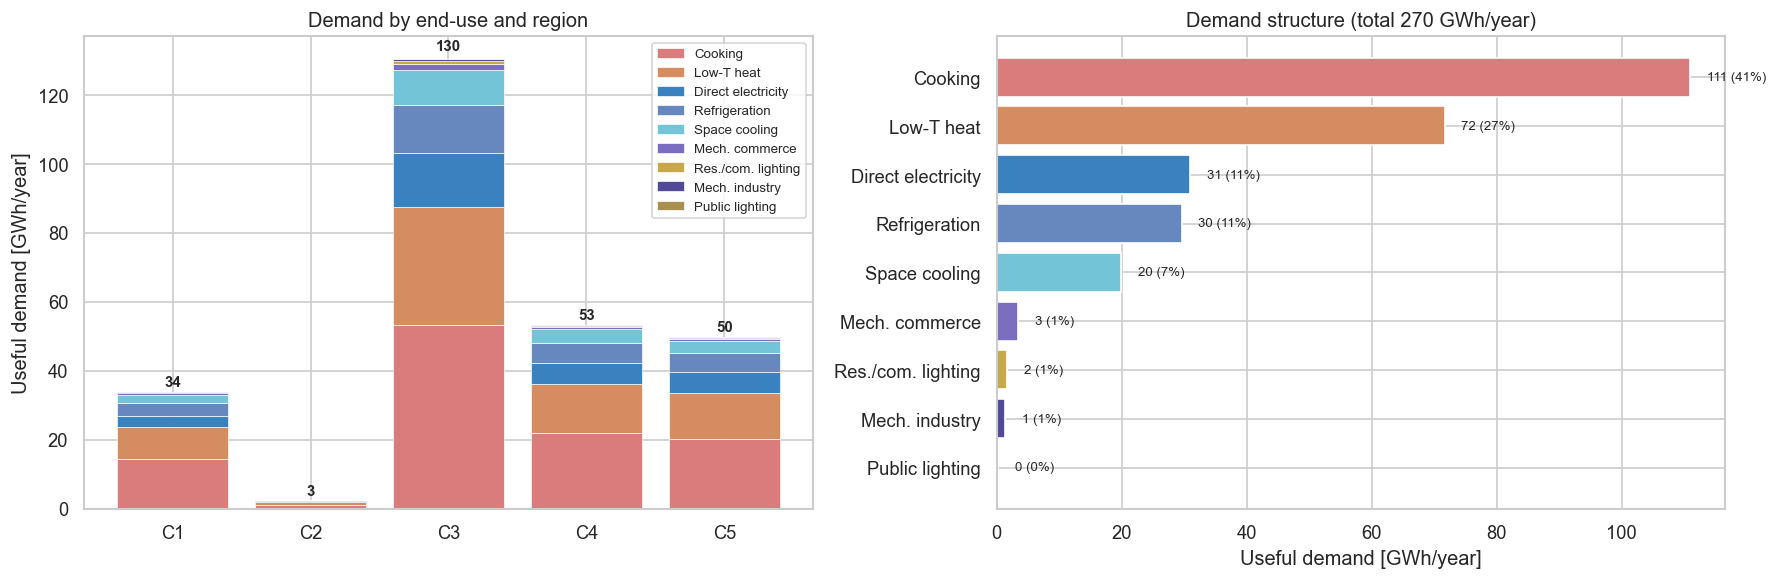

Useful demand by end-use and region [GWh/year]:
         COOKING  ELECTRICITY  SPACE_COOLING  FOOD_PRESERVATION  HEAT_LOW_T_DECEN  LIGHTING_R_C  LIGHTING_P  MECHANICAL_ENERGY_COMM  MECHANICAL_ENERGY_IND
Regions                                                                                                                                                   
C1         14.41         3.19           2.23               3.84              9.30          0.22        0.03                    0.44                   0.18
C2          1.07         0.32           0.19               0.28              0.68          0.02        0.00                    0.03                   0.01
C3         53.22        15.49          10.05              14.16             34.30          0.82        0.10                    1.65                   0.67
C4         22.02         5.94           3.99               5.83             14.14          0.33        0.04                    0.67                   0.26
C5         20.28      

In [5]:
dem = eud_demand(yb, REGIONS)
dem_sorted = dem[dem.sum().sort_values(ascending=False).index]   # dominant uses first

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
bottom = np.zeros(len(REGIONS)); x = np.arange(len(REGIONS))
for lay in dem_sorted.columns:
    ax.bar(x, dem_sorted[lay].values, bottom=bottom, label=eud_label(lay),
           color=eud_color(lay), edgecolor='white', linewidth=.4)
    bottom += dem_sorted[lay].values
for xi, tot in zip(x, dem.sum(axis=1).values):
    ax.text(xi, tot + tot*0.01 + 0.3, f'{tot:.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels([REGION_LABELS[r] for r in REGIONS])
ax.set_ylabel('Useful demand [GWh/year]')
ax.set_title('Demand by end-use and region')
ax.legend(fontsize=8, loc='upper right')

ax = axes[1]
shares = dem.sum().sort_values(ascending=True)
ax.barh(range(len(shares)), shares.values, color=[eud_color(l) for l in shares.index], edgecolor='white')
ax.set_yticks(range(len(shares))); ax.set_yticklabels([eud_label(l) for l in shares.index])
tot = shares.sum()
for i, v in enumerate(shares.values):
    ax.text(v + tot*0.01, i, f'{v:.0f} ({v/tot*100:.0f}%)', va='center', fontsize=8)
ax.set_xlabel('Useful demand [GWh/year]')
ax.set_title(f'Demand structure (total {tot:.0f} GWh/year)')
plt.tight_layout(); plt.show()

print('Useful demand by end-use and region [GWh/year]:')
print(dem.round(2).to_string())

---
## 3. Autonomy & import dependence  [complementary, not in the manuscript]

A central question for an **isolated** region: what share of energy is produced locally vs imported from outside (electricity from Brazil/SIN, diesel, LPG...)? Electricity imports and imported fossil resources (`Resources.csv`) are combined here.


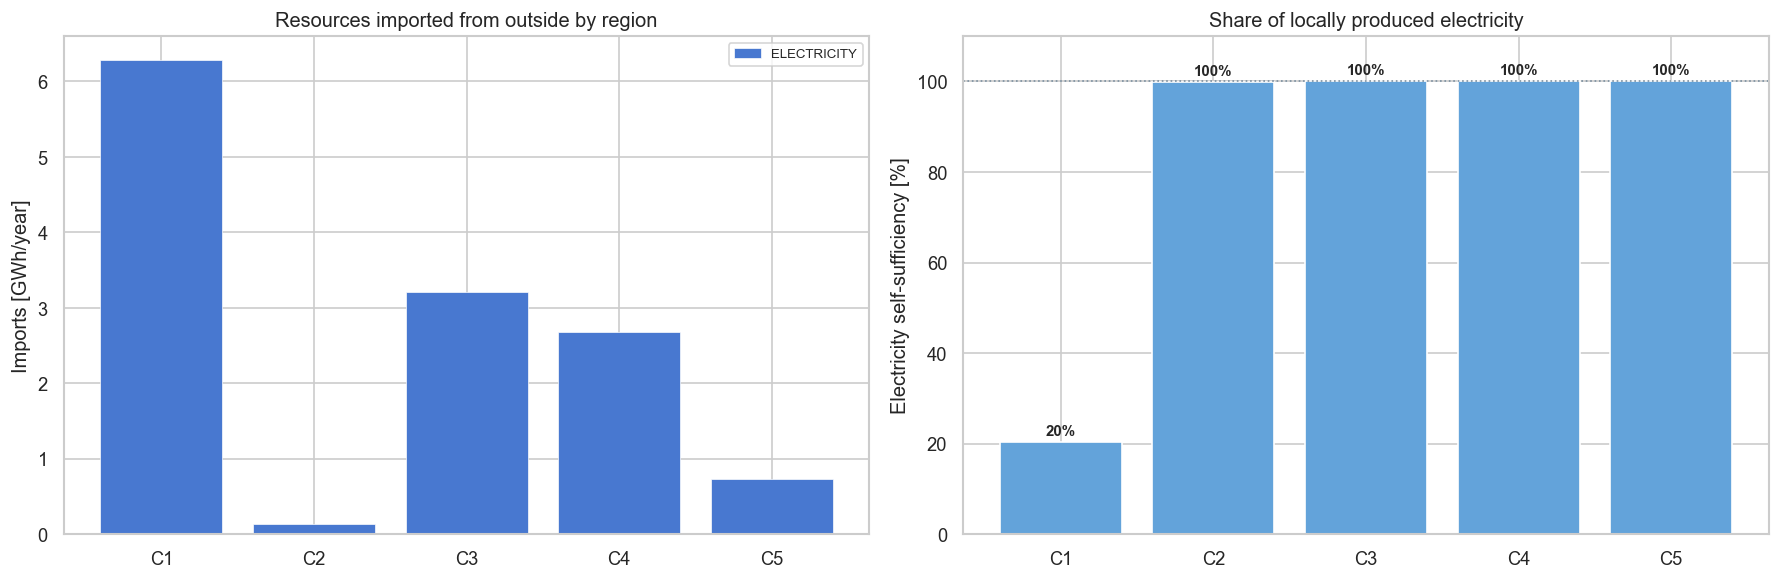

Imports by resource and region [GWh/year]:
Resources  ELECTRICITY
Regions               
C1                6.28
C2                0.14
C3                3.21
C4                2.67
C5                0.73


In [6]:
r = res_reg[res_reg['Regions'].isin(REGIONS)].copy()
imp = r[r['R_year_import'] > EPS].pivot_table(index='Regions', columns='Resources',
        values='R_year_import', aggfunc='sum', fill_value=0).reindex(REGIONS).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
imp_s = imp[imp.sum().sort_values(ascending=False).index] if not imp.empty else imp
bottom = np.zeros(len(REGIONS)); x = np.arange(len(REGIONS))
palette = sns.color_palette('muted', max(len(imp_s.columns), 1))
for c, col in zip(imp_s.columns, palette):
    ax.bar(x, imp_s[c].values, bottom=bottom, label=c, color=col, edgecolor='white', linewidth=.4)
    bottom += imp_s[c].values
ax.set_xticks(x); ax.set_xticklabels([REGION_LABELS[rr] for rr in REGIONS])
ax.set_ylabel('Imports [GWh/year]')
ax.set_title('Resources imported from outside by region')
ax.legend(fontsize=8)

ax = axes[1]
es = elec_supply(yb, REGIONS)
loc = es[~es['Elements'].isin(IMPORT_ELEC)].groupby('Regions')['val'].sum().reindex(REGIONS).fillna(0)
imp_el = es[es['Elements'].isin(IMPORT_ELEC)].groupby('Regions')['val'].sum().reindex(REGIONS).fillna(0)
tot_el = (loc + imp_el).replace(0, np.nan)
auto = (loc / tot_el * 100).fillna(0)
bars = ax.bar(x, auto.values, color="#63A3DA", edgecolor='white')
for b, v in zip(bars, auto.values):
    ax.text(b.get_x()+b.get_width()/2, v+1.5, f'{v:.0f}%', ha='center', fontsize=9, fontweight='bold')
ax.axhline(100, color='#7B8FA0', ls=':', lw=1)
ax.set_xticks(x); ax.set_xticklabels([REGION_LABELS[rr] for rr in REGIONS])
ax.set_ylabel('Electricity self-sufficiency [%]'); ax.set_ylim(0, 110)
ax.set_title('Share of locally produced electricity')
plt.tight_layout(); plt.show()

print('Imports by resource and region [GWh/year]:')
print((imp.round(2).to_string() if not imp.empty else '  no imports'))

---
## 4. Carbon footprint (GWP)  [complementary, not in the manuscript]

- **GWP_constr**: equipment manufacturing emissions
- **GWP_op**: operational emissions (combustion, processes)
- **CO2_net**: net balance

Intensity reported in **g CO2/kWh** of electricity produced.


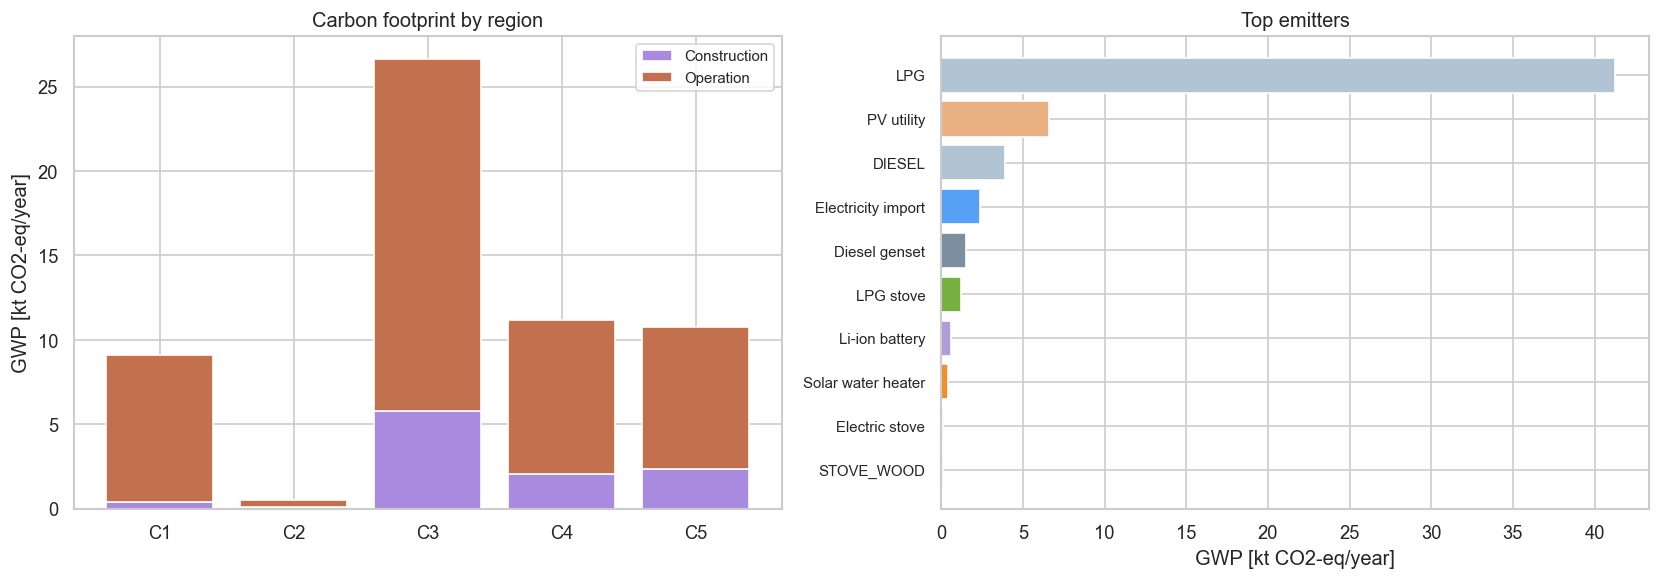

Total operational GWP  : 47.53 kt CO2-eq/year
Electricity intensity  : 299.5 g CO2/kWh produced


In [7]:
g = gwp_reg[gwp_reg['Regions'].isin(REGIONS)].copy()
for col in ['GWP_constr', 'GWP_op', 'CO2_net']:
    g[col] = g[col].fillna(0)
by_reg = g.groupby('Regions')[['GWP_constr', 'GWP_op']].sum().reindex(REGIONS).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
x = np.arange(len(REGIONS)); bottom = np.zeros(len(REGIONS))
for col in ['GWP_constr', 'GWP_op']:
    color, lab = GWP_COLORS[col], GWP_LABELS[col]
    ax.bar(x, by_reg[col].values, bottom=bottom, color=color, label=lab, edgecolor='white')
    bottom += by_reg[col].values
ax.set_xticks(x); ax.set_xticklabels(REGIONS)
ax.set_ylabel('GWP [kt CO2-eq/year]'); ax.set_title('Carbon footprint by region'); ax.legend(fontsize=9)

ax = axes[1]
g['tot'] = g['GWP_constr'] + g['GWP_op']
top = g.groupby('Elements')['tot'].sum().sort_values(ascending=False).head(10)
top = top[top > EPS]
if len(top):
    ax.barh(range(len(top)), top.values[::-1], color=[get_color(t) for t in top.index[::-1]], edgecolor='white')
    ax.set_yticks(range(len(top))); ax.set_yticklabels([get_label(t) for t in top.index[::-1]], fontsize=9)
    ax.set_xlabel('GWP [kt CO2-eq/year]'); ax.set_title('Top emitters')
else:
    ax.text(0.5, 0.5, 'Negligible emissions', ha='center', va='center')
plt.tight_layout(); plt.show()

elec_total = elec_supply(yb, REGIONS)['val'].sum()
co2_op = g['GWP_op'].sum()
print(f'Total operational GWP  : {co2_op:.2f} kt CO2-eq/year')
print(f'Electricity intensity  : {co2_op/elec_total*1000:.1f} g CO2/kWh produced')

---
## 5. Storage  [complementary, not in the manuscript]

Deployed storage assets: capacity `F` and annual cycled energy.


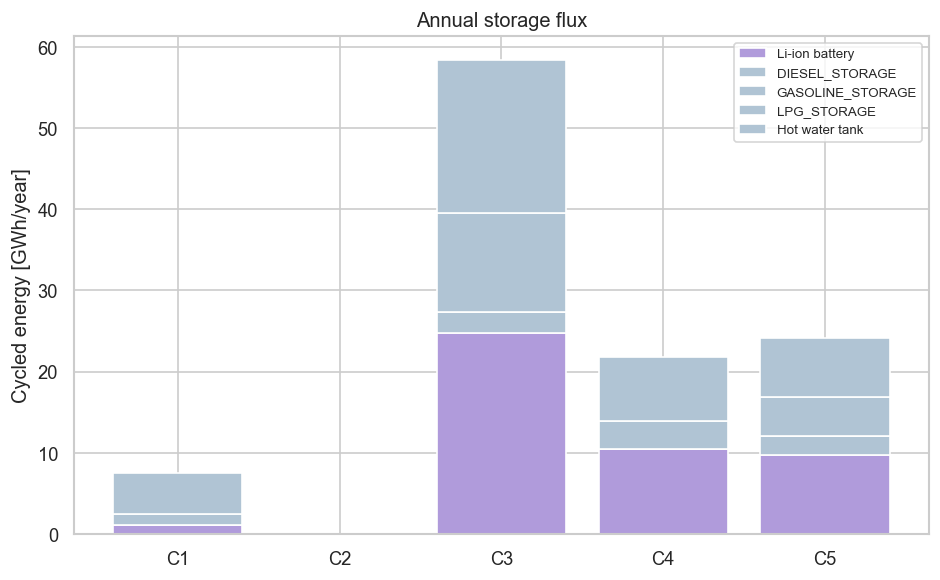

Active storage assets:
Regions       Technologies      F  Year_energy_flux  Losses
     C1            BATT_LI    NaN             1.095     NaN
     C1 TS_DEC_DIRECT_ELEC    NaN             5.027     NaN
     C1     DIESEL_STORAGE  3.931               NaN     NaN
     C1   GASOLINE_STORAGE  3.627               NaN     NaN
     C1        LPG_STORAGE    NaN             1.351     NaN
     C3            BATT_LI    NaN            24.740  -2.749
     C3 TS_DEC_DIRECT_ELEC    NaN            18.828  -2.006
     C3     DIESEL_STORAGE 19.277             2.600     NaN
     C3   GASOLINE_STORAGE 17.845               NaN     NaN
     C3        LPG_STORAGE  5.179            12.207     NaN
     C4            BATT_LI    NaN            10.459  -1.161
     C4 TS_DEC_DIRECT_ELEC    NaN             7.875     NaN
     C4     DIESEL_STORAGE  7.535               NaN     NaN
     C4   GASOLINE_STORAGE  6.975               NaN     NaN
     C4        LPG_STORAGE  1.894             3.493     NaN
     C5          

In [8]:
s = sto_reg[sto_reg['Regions'].isin(REGIONS)].copy()
s_act = s[s[['F', 'Year_energy_flux']].abs().max(axis=1) > EPS]

if s_act.empty:
    print('No active storage asset.')
else:
    fig, ax = plt.subplots(figsize=(8, 5))
    piv = s_act.pivot_table(index='Regions', columns='Technologies', values='Year_energy_flux',
                            aggfunc='sum', fill_value=0).reindex(REGIONS).fillna(0)
    x = np.arange(len(REGIONS)); bottom = np.zeros(len(REGIONS))
    for tech in piv.columns:
        ax.bar(x, piv[tech].values, bottom=bottom, label=get_label(tech), color=get_color(tech), edgecolor='white')
        bottom += piv[tech].values
    ax.set_xticks(x); ax.set_xticklabels(REGIONS)
    ax.set_ylabel('Cycled energy [GWh/year]'); ax.set_title('Annual storage flux'); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()

    print('Active storage assets:')
    print(s_act[['Regions', 'Technologies', 'F', 'Year_energy_flux', 'Losses']].round(3).to_string(index=False))

---
## 6. Curtailment & flexibility  [complementary, not in the manuscript]

Available renewable energy that is **not used**. Low curtailment indicates well-sized flexibility (storage); high curtailment signals poorly valorised solar surplus.


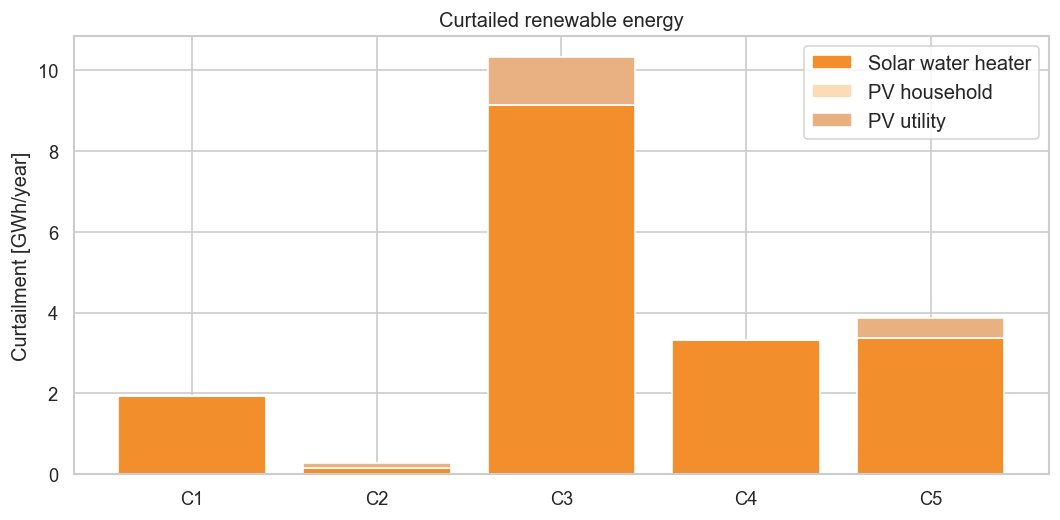

Curtailment total : 19.748 GWh/year
Overall rate      : 12.16 % of renewable potential
Regions Technologies   Curt
     C1   PV_UTILITY 0.0004
     C1        PV_HS 0.0001
     C1    DEC_SOLAR 1.9439
     C2   PV_UTILITY 0.1277
     C2    DEC_SOLAR 0.1554
     C2        PV_HS 0.0001
     C3    DEC_SOLAR 9.1405
     C3        PV_HS 0.0001
     C3   PV_UTILITY 1.1818
     C4        PV_HS 0.0001
     C4    DEC_SOLAR 3.3223
     C4   PV_UTILITY 0.0008
     C5        PV_HS 0.0001
     C5   PV_UTILITY 0.4976
     C5    DEC_SOLAR 3.3771


In [9]:
cu = curt_reg[curt_reg['Regions'].isin(REGIONS)].copy()
cu = cu[cu['Curt'] > EPS]
es = elec_supply(yb, REGIONS)

if cu.empty:
    print('OK Curtailment negligible - all renewable production is valorised.')
else:
    piv = cu.pivot_table(index='Regions', columns='Technologies', values='Curt', aggfunc='sum', fill_value=0).reindex(REGIONS).fillna(0)
    fig, ax = plt.subplots(figsize=(9, 4.5))
    x = np.arange(len(REGIONS)); bottom = np.zeros(len(REGIONS))
    for tech in piv.columns:
        ax.bar(x, piv[tech].values, bottom=bottom, label=get_label(tech), color=get_color(tech), edgecolor='white')
        bottom += piv[tech].values
    ax.set_xticks(x); ax.set_xticklabels(REGIONS)
    ax.set_ylabel('Curtailment [GWh/year]'); ax.set_title('Curtailed renewable energy'); ax.legend(fontsize=12)
    plt.tight_layout(); plt.show()

    prod_renew = es[es['Elements'].isin(RENEW_ELEC)]['val'].sum()
    tot_curt = cu['Curt'].sum()
    print(f'Curtailment total : {tot_curt:.3f} GWh/year')
    print(f'Overall rate      : {tot_curt/(tot_curt+prod_renew)*100:.2f} % of renewable potential')
    print(cu[['Regions', 'Technologies', 'Curt']].round(4).to_string(index=False))

---
## 7. Inter-regional exchanges  [complementary, not in the manuscript]

Annual flows exchanged between cells (power lines, fuel transport). Reveals regional specialisation and potential hub roles.


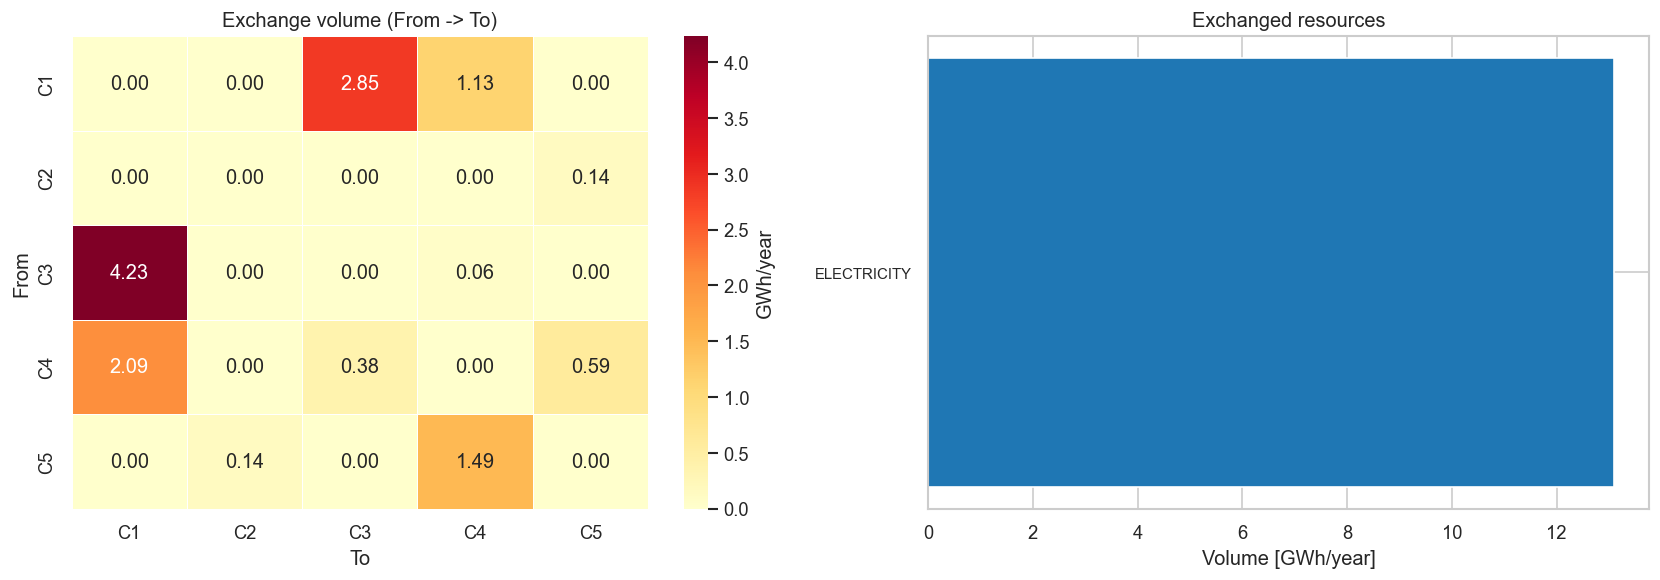

From To   Resources  Exchanges_year
  C1 C3 ELECTRICITY           2.850
  C1 C4 ELECTRICITY           1.129
  C2 C5 ELECTRICITY           0.138
  C3 C1 ELECTRICITY           4.234
  C3 C4 ELECTRICITY           0.065
  C4 C1 ELECTRICITY           2.091
  C4 C3 ELECTRICITY           0.376
  C4 C5 ELECTRICITY           0.590
  C5 C2 ELECTRICITY           0.139
  C5 C4 ELECTRICITY           1.492


In [10]:
e = exch_reg.copy()
e['Exchanges_year'] = e['Exchanges_year'].fillna(0)
cross = e[(e['From'].isin(REGIONS)) & (e['To'].isin(REGIONS)) &
          (e['From'] != e['To']) & (e['Exchanges_year'].abs() > EPS)]

if cross.empty:
    print('No significant inter-regional exchange (near-isolated cells).')
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ax = axes[0]
    mat = cross.groupby(['From', 'To'])['Exchanges_year'].sum().unstack(fill_value=0).reindex(index=REGIONS, columns=REGIONS, fill_value=0)
    sns.heatmap(mat, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax, linewidths=.5, cbar_kws={'label': 'GWh/year'})
    ax.set_title('Exchange volume (From -> To)'); ax.set_xlabel('To'); ax.set_ylabel('From')
    ax = axes[1]
    byres = cross.groupby('Resources')['Exchanges_year'].sum().sort_values(ascending=True)
    byres = byres[byres.abs() > EPS]
    ax.barh(range(len(byres)), byres.values, color=sns.color_palette('tab10', len(byres)))
    ax.set_yticks(range(len(byres))); ax.set_yticklabels(byres.index, fontsize=9)
    ax.set_xlabel('Volume [GWh/year]'); ax.set_title('Exchanged resources')
    plt.tight_layout(); plt.show()
    print(cross[['From', 'To', 'Resources', 'Exchanges_year']].round(3).to_string(index=False))

---
## 8. Hourly profiles - electric dispatch vs demand  [manuscript figure 17]

EnergyScope represents the year with **16 typical days**. Production (stacked by technology) and
electricity demand (black curve) are overlaid to see how supply follows load, typical day by
typical day.

The panels are a mirror plot around zero, built on the model's own `layer_balance` equation
(`ESMC_model_AMPL.mod`, Eq. 13) for the ELECTRICITY layer, rearranged so that every term sits on
the side it physically belongs to:

* **above 0**: production by technology, SIN import, net inter-cluster import, BATT_LI and BATT_HS
  discharge;
* **below 0**: battery charge, network losses, net inter-cluster export;
* **line**: final end-use demand alone, the electricity actually delivered to uses, with neither
  losses nor storage charge folded in.

So (sum of bars above) - (sum of bars below) = the line, at every hour.

Two demand terms are invisible to a naive `active_consumers` reading of `Layers_in_out`:
`End_uses[ELECTRICITY]` (direct demand, routed through no technology: `end_uses_input` x the
normalised electricity time series) and `Network_losses` (`loss_network` x grid-connected
production + SIN import, the off-grid `TECH_HS` set PV_HS / HS_DIESEL / BATT_HS being excluded from
that loss). Battery charge is invisible too, storage being absent from `Layers_in_out`.

The cell loads the sufficiency scenario directly rather than relying on the notebook's main
`SCENARIO`, so its output does not depend on what is configured above.


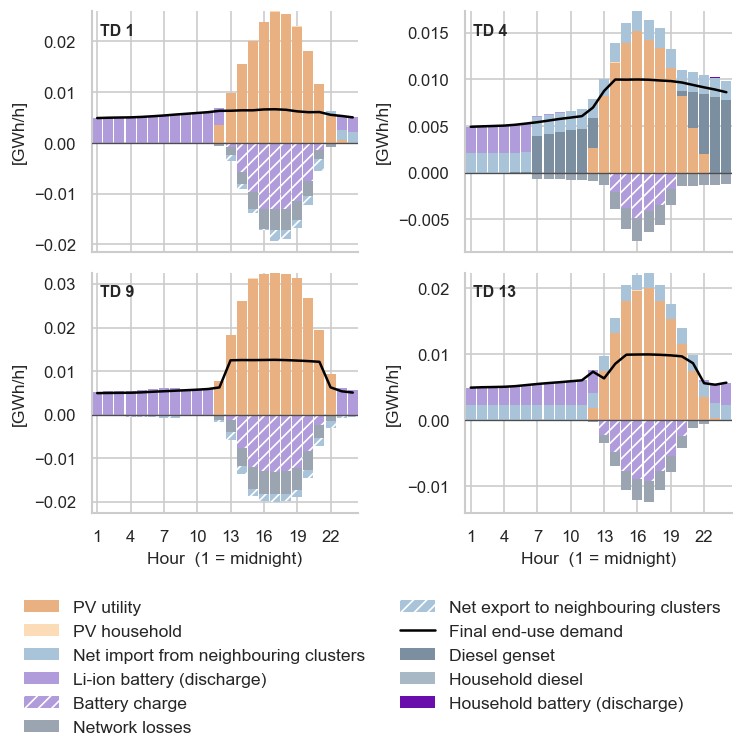

Region : C3  |  Scenario : norte_amazonia_sufficiency_2025  |  Typical days shown : [1, 4, 9, 13]
Daily totals [GWh/day], mirror balance (above - below = end-use demand):
  TD  1   above =   0.256   below =   0.118   above-below =   0.139   demand =   0.139
  TD  4   above =   0.225   below =   0.045   above-below =   0.180   demand =   0.180
  TD  9   above =   0.342   below =   0.149   above-below =   0.194   demand =   0.194
  TD 13   above =   0.236   below =   0.070   above-below =   0.166   demand =   0.166
Max hourly |residual| over the 4 typical days : 1.04e-06 GWh/h


In [11]:
import re

DISPATCH_SCENARIO = 'norte_amazonia_sufficiency_2025'
DISPATCH_BASE = ROOT / DISPATCH_SCENARIO / 'outputs'
DISPATCH_HOURLY = DISPATCH_BASE / 'hourly_results'
DISPATCH_REG = DISPATCH_BASE / 'regional_results'
DISPATCH_DATA_DIR = DATA / 'sufficiency'
REGION_ANALYSE = 'C3'
TD_SHOW = [1, 4, 9, 13]
HOURS = list(range(1, 25))

ft = pd.read_csv(DISPATCH_HOURLY / 'F_t.csv', sep=';')
ft['F_t'] = pd.to_numeric(ft['F_t'], errors='coerce').fillna(0)

# Storage_power.csv: Storage_out >= 0 (discharge), Storage_in <= 0 (charge)
sp = pd.read_csv(DISPATCH_HOURLY / 'Storage_power.csv', sep=';')
sp['Storage_out'] = pd.to_numeric(sp['Storage_out'], errors='coerce').fillna(0)
sp['Storage_in'] = pd.to_numeric(sp['Storage_in'], errors='coerce').fillna(0)

# R_t_exterior.csv: hourly resource imports from outside the cell (SIN import)
rt_ext = pd.read_csv(DISPATCH_HOURLY / 'R_t_exterior.csv', sep=';')
rt_ext['R_t_exterior'] = pd.to_numeric(rt_ext['R_t_exterior'], errors='coerce').fillna(0)

# Exchanges.csv: hourly inter-cluster ELECTRICITY exchange. Anchored at
# From == region: Exch_exp = what the region sends (pre-loss), Exch_imp =
# what it receives (post-loss, stored as a negative value on this row when
# the link is reversed relative to the row's own (From, To) direction).
exch = pd.read_csv(DISPATCH_HOURLY / 'Exchanges.csv', sep=';')
for c in ['Exch_exp', 'Exch_imp']:
    exch[c] = pd.to_numeric(exch[c], errors='coerce')

# Layers_in_out: electricity consumers (coef < 0) -> |coef| used to weight F_t
lio = pd.read_csv(DISPATCH_DATA_DIR / '00_INDEP' / 'Layers_in_out.csv', sep=';', index_col=0)
elec_consumer_coef = lio[lio['ELECTRICITY'] < 0]['ELECTRICITY'].abs()
active_consumers = elec_consumer_coef.index.intersection(ft['Technologies'].unique())

yb_disp = pd.read_csv(DISPATCH_REG / 'Year_balance.csv', sep=';')
yb_disp['ELECTRICITY'] = pd.to_numeric(yb_disp['ELECTRICITY'], errors='coerce').fillna(0)
gen_techs = set(elec_supply(yb_disp, REGIONS)['Elements']) - IMPORT_ELEC
GEN_ORDER = [t for t in ['PV_UTILITY', 'GENSET_DIESEL', 'PV_HS', 'HS_DIESEL'] if t in gen_techs]
GRID_GEN_TECHS = sorted(gen_techs - {'PV_HS', 'HS_DIESEL'})   # off-grid TECH_HS excluded from network losses

# Each sink below zero keeps the colour of the source it mirrors, so a mirrored pair reads as
# one flow seen from its two sides. The two sinks that would otherwise duplicate a source's
# legend swatch are hatched instead; the losses have no counterpart above zero and take a
# neutral grey.
COLOR_LOSSES = '#9AA5B1'
COLOR_EXCHANGE = '#A9C4D9'
SINK_HATCH = '///'


def _elec_end_uses_input(data_dir, region):
    '''end_uses_input[region,'ELECTRICITY'] (GWh/yr): annual direct-electricity
    demand, summed across sectors from Demands.csv - the model's own definition,
    not routed through any specific technology.'''
    dm = pd.read_csv(Path(data_dir) / region / 'Demands.csv', sep=';')
    row = dm[dm['parameter name'] == 'ELECTRICITY']
    cols = [c for c in dm.columns if c not in ('Category', 'Subcategory', 'parameter name', 'Units')]
    return row[cols].apply(pd.to_numeric, errors='coerce').sum(axis=1).sum()


def _electricity_time_series(scenario_base, region):
    '''{(hour, TD): normalised share}, read straight from the solved case's own
    reg_16TD.dat - the exact electricity_time_series[region, h, td] AMPL
    parameter, not re-derived from the raw 8760h Time_series.csv (which would
    also need the TD -> representative-day mapping).'''
    lines = (scenario_base.parent / 'reg_16TD.dat').read_text().splitlines()
    start = next(i for i, l in enumerate(lines) if l.strip().startswith(f'["{region}",*,*]'))
    ts = {}
    for line in lines[start + 1: start + 1 + 24]:
        parts = line.split()
        h = int(parts[0])
        for td_idx, val in enumerate(parts[1:], start=1):
            ts[(h, td_idx)] = float(val)
    return ts


def _loss_network_electricity(scenario_base):
    '''loss_network['ELECTRICITY'] (fraction): grid distribution loss applied to
    grid-connected production + SIN import in the model's Network_losses
    equation.'''
    text = (scenario_base.parent / 'indep.dat').read_text()
    m = re.search(r'ELECTRICITY\s+([\d.eE+-]+)', text.split('loss_network')[1])
    return float(m.group(1))


end_uses_input_elec = _elec_end_uses_input(DISPATCH_DATA_DIR, REGION_ANALYSE)
elec_ts = _electricity_time_series(DISPATCH_BASE, REGION_ANALYSE)
LOSS_NETWORK_ELEC = _loss_network_electricity(DISPATCH_BASE)

# Print charter for every chapter figure: reproduced at about 16 cm in the page, so a point
# here is a printed point. Axis labels, tick labels and legends sit in the 9.5-10.5 pt band,
# inline value labels one step below at 8.5 pt.
PRINT_RC = {
    'font.size': 10, 'axes.titlesize': 10.5, 'axes.labelsize': 10.5,
    'legend.fontsize': 9.5, 'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
}
plt.rcParams.update(PRINT_RC)
CM = 1 / 2.54

fig, axes = plt.subplots(2, 2, figsize=(16 * CM, 12.5 * CM), sharex=True)
all_handles = {}
report = {}

for ax, td in zip(axes.ravel(), TD_SHOW):
    def _hourly(df, mask, col):
        return df[mask].groupby('Hours')[col].sum().reindex(HOURS, fill_value=0)

    mask_gen = ((ft['Regions'] == REGION_ANALYSE) & (ft['Typical_days'] == td)
                & ft['Technologies'].isin(gen_techs) & (ft['F_t'] > EPS))
    gen = (ft[mask_gen]
           .pivot_table(index='Hours', columns='Technologies', values='F_t', aggfunc='sum', fill_value=0)
           .reindex(index=HOURS, columns=GEN_ORDER, fill_value=0).fillna(0))

    elec_imp = _hourly(rt_ext, ((rt_ext['Regions'] == REGION_ANALYSE) & (rt_ext['Typical_days'] == td)
                                 & (rt_ext['Resources'] == 'ELECTRICITY')), 'R_t_exterior')

    def storage(tech, col):
        return _hourly(sp, ((sp['Regions'] == REGION_ANALYSE) & (sp['Typical_days'] == td)
                            & (sp['Storage_tech'] == tech)), col)

    batt_li_dis, batt_hs_dis = storage('BATT_LI', 'Storage_out'), storage('BATT_HS', 'Storage_out')
    batt_charge = -(storage('BATT_LI', 'Storage_in') + storage('BATT_HS', 'Storage_in'))  # Storage_in <= 0

    exr = exch[(exch['Resources'] == 'ELECTRICITY') & (exch['Typical_days'] == td)
               & (exch['From'] == REGION_ANALYSE) & (exch['To'] != REGION_ANALYSE)]
    exch_out = exr.groupby('Hours')['Exch_exp'].sum().reindex(HOURS, fill_value=0).fillna(0)
    exch_in = -exr.groupby('Hours')['Exch_imp'].sum().reindex(HOURS, fill_value=0).fillna(0)
    net_import = (exch_in - exch_out).clip(lower=0)
    net_export = (exch_out - exch_in).clip(lower=0)

    grid_gen = gen.reindex(columns=GRID_GEN_TECHS, fill_value=0).sum(axis=1)
    net_losses = LOSS_NETWORK_ELEC * (grid_gen + elec_imp)

    mask_dem = ((ft['Regions'] == REGION_ANALYSE) & (ft['Typical_days'] == td)
                & ft['Technologies'].isin(active_consumers))
    dem_df = ft[mask_dem].copy()
    dem_df['contrib'] = dem_df['F_t'] * dem_df['Technologies'].map(elec_consumer_coef.to_dict())
    named_consumers = dem_df.groupby('Hours')['contrib'].sum().reindex(HOURS, fill_value=0)
    direct_demand = pd.Series({h: end_uses_input_elec * elec_ts[(h, td)] for h in HOURS})
    end_use_demand = named_consumers + direct_demand

    above = [(get_label(t), gen[t], get_color(t), None) for t in GEN_ORDER]
    above += [('Electricity import (SIN)', elec_imp, get_color('ELECTRICITY'), None),
              ('Net import from neighbouring clusters', net_import, COLOR_EXCHANGE, None),
              ('Li-ion battery (discharge)', batt_li_dis, get_color('BATT_LI'), None),
              ('Household battery (discharge)', batt_hs_dis, get_color('BATT_HS'), None)]
    below = [('Battery charge', batt_charge, get_color('BATT_LI'), SINK_HATCH),
             ('Network losses', net_losses, COLOR_LOSSES, None),
             ('Net export to neighbouring clusters', net_export, COLOR_EXCHANGE, SINK_HATCH)]

    for stack, sign in ((above, 1.0), (below, -1.0)):
        bottom = np.zeros(len(HOURS))
        for label, series, color, hatch in stack:
            vals = sign * series.values
            if np.abs(vals).sum() <= EPS:
                continue
            h = ax.bar(HOURS, vals, bottom=bottom, color=color, width=0.9, hatch=hatch,
                       edgecolor=('white' if hatch else 'none'), linewidth=0.0)
            bottom = bottom + vals
            all_handles.setdefault(label, h[0])

    line, = ax.plot(HOURS, end_use_demand.values, color='black', lw=1.5, zorder=5)
    all_handles.setdefault('Final end-use demand', line)
    ax.axhline(0, color='#4D4D4D', lw=0.8, zorder=4)

    # closure check: (bars above) - (bars below) must equal the line
    tot_above = sum(s for _, s, _, _ in above)
    tot_below = sum(s for _, s, _, _ in below)
    residual = (tot_above - tot_below - end_use_demand).abs()
    report[td] = dict(above=float(tot_above.sum()), below=float(tot_below.sum()),
                       demand=float(end_use_demand.sum()), max_residual=float(residual.max()))

    ax.annotate(f'TD {td}', xy=(0.03, 0.90), xycoords='axes fraction', fontsize=9.5, fontweight='bold')
    ax.set_xlim(0.5, 24.5)
    ax.set_xticks(range(1, 25, 3))
    ax.set_ylabel('[GWh/h]')

for ax in axes[1, :]:
    ax.set_xlabel('Hour  (1 = midnight)')

plt.tight_layout()
# Legend hung under the figure rather than over it: at three rows it would otherwise reach
# down into the first panel and collide with its TD tag.
fig.legend(all_handles.values(), all_handles.keys(),
           loc='upper center', ncol=2, fontsize=10.5, bbox_to_anchor=(0.5, 0.0), frameon=False)
plt.show()

print(f'Region : {REGION_ANALYSE}  |  Scenario : {DISPATCH_SCENARIO}  |  Typical days shown : {TD_SHOW}')
print('Daily totals [GWh/day], mirror balance (above - below = end-use demand):')
for td in TD_SHOW:
    r = report[td]
    print(f'  TD {td:>2d}   above = {r["above"]:7.3f}   below = {r["below"]:7.3f}   '
          f'above-below = {r["above"] - r["below"]:7.3f}   demand = {r["demand"]:7.3f}')
print(f'Max hourly |residual| over the 4 typical days : '
      f'{max(r["max_residual"] for r in report.values()):.2e} GWh/h')

---
## 9. Summary

Summary table for the scenario. Reading guide for the write-up:

1. **Demand** - which uses dominate (cooking? refrigeration?) and why (Amazonian climate,
   sufficiency vs reality)?
2. **Supply** - why does PV dominate? what role for diesel and imports?
3. **Autonomy** - which regions depend most on external supply?
4. **Cost** - why is the most expensive region the most expensive (demand, resource, isolation)?
5. **Robustness** - which technologies appear in every scenario (no-regret) and which are
   sensitive to demand? See section 10.

In [12]:
es = elec_supply(yb, REGIONS)
dem = eud_demand(yb, REGIONS)
elec_total = es['val'].sum()
elec_renew = es[es['Elements'].isin(RENEW_ELEC)]['val'].sum()
elec_imp = es[es['Elements'].isin(IMPORT_ELEC)]['val'].sum()

print(f'SUMMARY - {SCENARIO}')
print(f'  Total system cost          : {total_cost["TotalCost"].sum():>8.2f} M€/year')
print(f'  Useful demand served       : {dem.values.sum():>8.1f} GWh/year')
print(f'  Average cost               : {total_cost["TotalCost"].sum()*1000/dem.values.sum():>8.1f} EUR/MWh useful')
print(f'  Electricity production     : {elec_total:>8.1f} GWh/year')
print(f'     of which local renewable: {elec_renew/elec_total*100:>8.1f} %')
print(f'     of which imported       : {elec_imp/elec_total*100:>8.1f} %')
print(f'  CO2 emissions (op.)        : {gwp_reg["GWP_op"].fillna(0).sum():>8.2f} kt/year')
print('  Dominant use by region   :')
for rg in REGIONS:
    top_use = dem.loc[rg].idxmax()
    print(f'    {rg} : demand {dem.loc[rg].sum():6.1f} GWh  .  top use = {eud_label(top_use)} ({dem.loc[rg].max():.1f} GWh)')


SUMMARY - norte_amazonia_sufficiency_2025
  Total system cost          :    31.28 M€/year
  Useful demand served       :    270.0 GWh/year
  Average cost               :    115.8 EUR/MWh useful
  Electricity production     :    158.7 GWh/year
     of which local renewable:     89.9 %
     of which imported       :      8.8 %
  CO2 emissions (op.)        :    47.53 kt/year
  Dominant use by region   :
    C1 : demand   33.8 GWh  .  top use = Cooking (14.4 GWh)
    C2 : demand    2.6 GWh  .  top use = Cooking (1.1 GWh)
    C3 : demand  130.5 GWh  .  top use = Cooking (53.2 GWh)
    C4 : demand   53.2 GWh  .  top use = Cooking (22.0 GWh)
    C5 : demand   49.9 GWh  .  top use = Cooking (20.3 GWh)


---
## 10. Scenario comparison - Universal sufficiency vs Current system vs Supply transition vs Universal access  [complementary, not in the manuscript]

Comparison of **`norte_amazonia_sufficiency_2025`** (universal sufficiency, reference), **`norte_amazonia_reality_2025`** (current system), **`norte_amazonia_reality_2025_phase2`** (supply transition, centralised grid reinforcement) and **`norte_amazonia_reality_access_2025`** (universal access) on key indicators: demand, electricity mix, costs, carbon footprint.

All deltas are expressed **relative to Universal sufficiency**.


In [13]:
DS = {lab: load_scenario(ROOT / scen / 'outputs') for lab, scen in COMPARE.items()}

def kpis(D):
    yb_  = D['yb']
    tc   = D['total_cost']; tc = tc[tc['Regions'].isin(REGIONS)]
    es_  = elec_supply(yb_, REGIONS)
    dem_ = eud_demand(yb_, REGIONS)
    elec_tot   = es_['val'].sum()
    elec_renew = es_[es_['Elements'].isin(RENEW_ELEC)]['val'].sum()
    elec_imp   = es_[es_['Elements'].isin(IMPORT_ELEC)]['val'].sum()
    cost_tot   = tc['TotalCost'].sum()
    demand_tot = dem_.values.sum()
    co2_op     = pd.to_numeric(D['gwp']['GWP_op'], errors='coerce').fillna(0).sum()
    n_tech     = (D['assets'][D['assets']['F'] > EPS])['Technologies'].nunique()
    return {
        'Total cost (M€/year)':     round(cost_tot, 2),
        'Useful demand (GWh/year)': round(demand_tot, 1),
        'Average cost (€/MWh)':     round(cost_tot * 1000 / demand_tot, 1),
        'Elec. prod. (GWh/year)':   round(elec_tot, 1),
        'Renewable share (%)':      round(elec_renew / elec_tot * 100, 1),
        'Elec. import share (%)':   round(elec_imp / elec_tot * 100, 1),
        'GWP op. (kt CO2/year)':    round(co2_op, 2),
        'Deployed techs':           n_tech,
    }

comp = pd.DataFrame({lab: kpis(D) for lab, D in DS.items()})[list(COMPARE)]
for lab in COMPARE:
    if lab != SCEN_REF:
        comp[f'{lab} vs ref (%)'] = ((comp[lab] - comp[SCEN_REF]) / comp[SCEN_REF].abs() * 100).round(1)

print(f'COMPARISON TABLE  -  reference = {SCEN_REF}')
print(comp.to_string())

COMPARISON TABLE  -  reference = Universal sufficiency
                          Universal sufficiency  Current system  Supply transition  Universal access  Access transition  Current system vs ref (%)  Supply transition vs ref (%)  Universal access vs ref (%)  Access transition vs ref (%)
Total cost (M€/year)                      31.28           66.51              42.15             69.02              47.07                      112.6                          34.8                        120.7                          50.5
Useful demand (GWh/year)                 270.00          327.20             333.10            363.50             368.00                       21.2                          23.4                         34.6                          36.3
Average cost (€/MWh)                     115.80          203.30             126.50            189.90             127.90                       75.6                           9.2                         64.0                          10.4
E

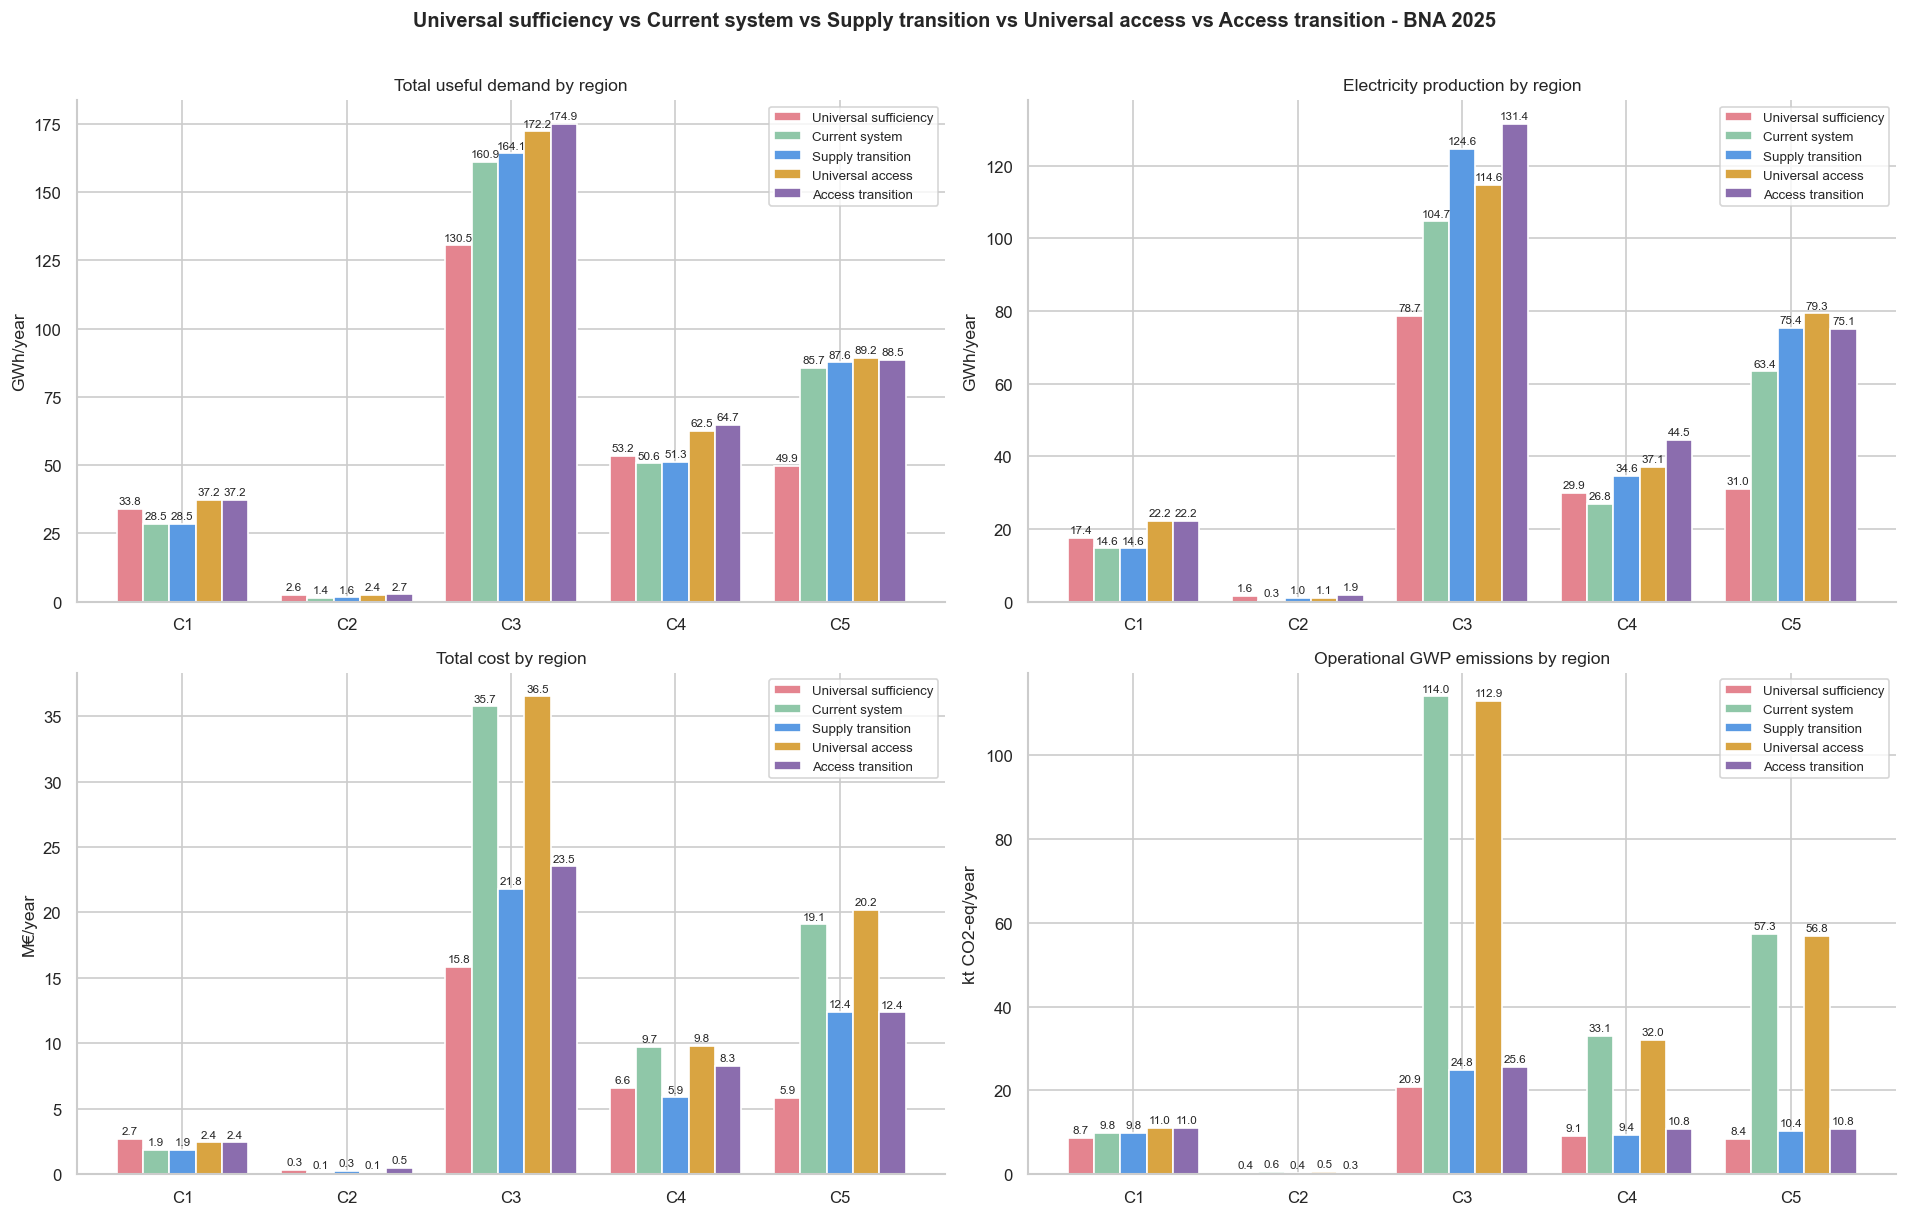

In [14]:
def by_region(D, what):
    if what == 'demand':
        return eud_demand(D['yb'], REGIONS).sum(axis=1).reindex(REGIONS).fillna(0)
    if what == 'elec':
        return elec_supply(D['yb'], REGIONS).groupby('Regions')['val'].sum().reindex(REGIONS).fillna(0)
    if what == 'cost':
        c = D['cost'][D['cost']['Regions'].isin(REGIONS)]
        return c.groupby('Regions')[['C_inv', 'C_maint', 'C_op']].sum().sum(axis=1).reindex(REGIONS).fillna(0)
    if what == 'gwp':
        g = D['gwp'][D['gwp']['Regions'].isin(REGIONS)]
        return g.groupby('Regions')['GWP_op'].sum().reindex(REGIONS).fillna(0)
    raise ValueError(what)

PANELS = [('demand', 'Total useful demand by region',        'GWh/year'),
          ('elec',   'Electricity production by region',     'GWh/year'),
          ('cost',   'Total cost by region',                 'M€/year'),
          ('gwp',    'Operational GWP emissions by region',  'kt CO2-eq/year')]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
x = np.arange(len(REGIONS)); n = len(COMPARE); w = 0.8 / n

for ax, (what, title, unit) in zip(axes.ravel(), PANELS):
    vals = {lab: by_region(D, what) for lab, D in DS.items()}
    vmax = max(v.max() for v in vals.values()) or 1
    for k, (lab, v) in enumerate(vals.items()):
        bars = ax.bar(x + (k - (n - 1) / 2) * w, v.values, w,
                      color=SCEN_COLORS[lab], label=lab, edgecolor='white')
        for b, val in zip(bars, v.values):
            ax.text(b.get_x() + b.get_width() / 2, val + vmax * 0.01, f'{val:.1f}',
                    ha='center', fontsize=7)
    ax.set_xticks(x); ax.set_xticklabels(REGIONS)
    ax.set_ylabel(unit); ax.set_title(title); ax.legend(fontsize=8)

plt.suptitle(' vs '.join(COMPARE) + ' - BNA 2025',
             fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

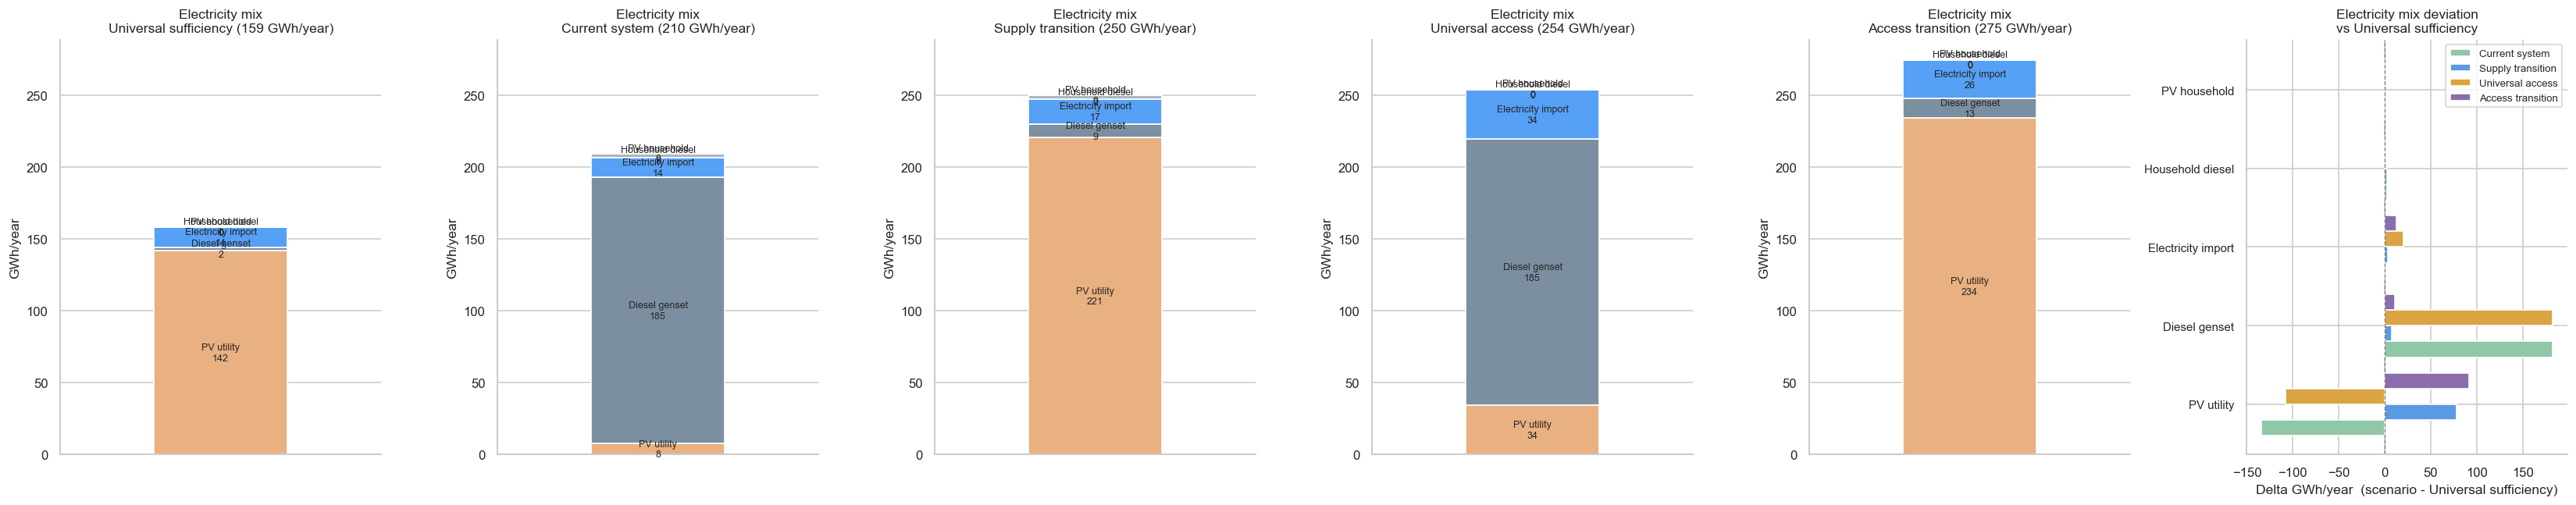

In [15]:
mixes = {lab: elec_supply(D['yb'], REGIONS).groupby('Elements')['val'].sum()
         for lab, D in DS.items()}
all_techs = sorted(set().union(*[set(m.index) for m in mixes.values()]),
                   key=lambda t: -sum(m.get(t, 0) for m in mixes.values()))

n = len(COMPARE)
fig, axes = plt.subplots(1, n + 1, figsize=(4.6 * (n + 1), 5.5))

for ax, (lab, mix) in zip(axes[:n], mixes.items()):
    bottom = 0
    for t in all_techs:
        v = mix.get(t, 0)
        if v > EPS:
            ax.bar(0, v, bottom=bottom, color=get_color(t), width=0.5)
            ax.text(0, bottom + v / 2, f'{get_label(t)}\n{v:.0f}',
                    ha='center', va='center', fontsize=7.5)
            bottom += v
    ax.set_xlim(-0.6, 0.6); ax.set_xticks([]); ax.set_ylabel('GWh/year')
    ax.set_title(f'Electricity mix\n{lab} ({mix.sum():.0f} GWh/year)')

ymax = max(ax.get_ylim()[1] for ax in axes[:n])     # shared scale -> panels comparable
for ax in axes[:n]:
    ax.set_ylim(0, ymax)

ax = axes[n]
others  = [lab for lab in COMPARE if lab != SCEN_REF]
techs_d = [t for t in all_techs
           if any(abs(mixes[l].get(t, 0) - mixes[SCEN_REF].get(t, 0)) > EPS for l in others)]
y = np.arange(len(techs_d)); h = 0.8 / len(others)
for k, lab in enumerate(others):
    d = [mixes[lab].get(t, 0) - mixes[SCEN_REF].get(t, 0) for t in techs_d]
    ax.barh(y + (k - (len(others) - 1) / 2) * h, d, h,
            color=SCEN_COLORS[lab], label=lab, edgecolor='white')
ax.set_yticks(y); ax.set_yticklabels([get_label(t) for t in techs_d], fontsize=9)
ax.axvline(0, color='grey', lw=0.8, ls='--')
ax.set_xlabel(f'Delta GWh/year  (scenario - {SCEN_REF})')
ax.set_title(f'Electricity mix deviation\nvs {SCEN_REF}'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

source: bolivia-energy-data/analyse_GIS_projections\output\2024\cluster_summary.csv
CRF(10%, 30 years) = 0.10608   (applied upstream)

GRID EXTENSION  -  charged to: Access transition, Universal access, Universal sufficiency
Region   CAPEX total (M-euro) Annualised CRF (M-euro/yr)
C1                     13.366                      1.418
C2                      1.246                      0.132
C3                      7.253                      0.769
C4                     15.561                      1.651
C5                      0.203                      0.021
TOTAL                  37.629                      3.992


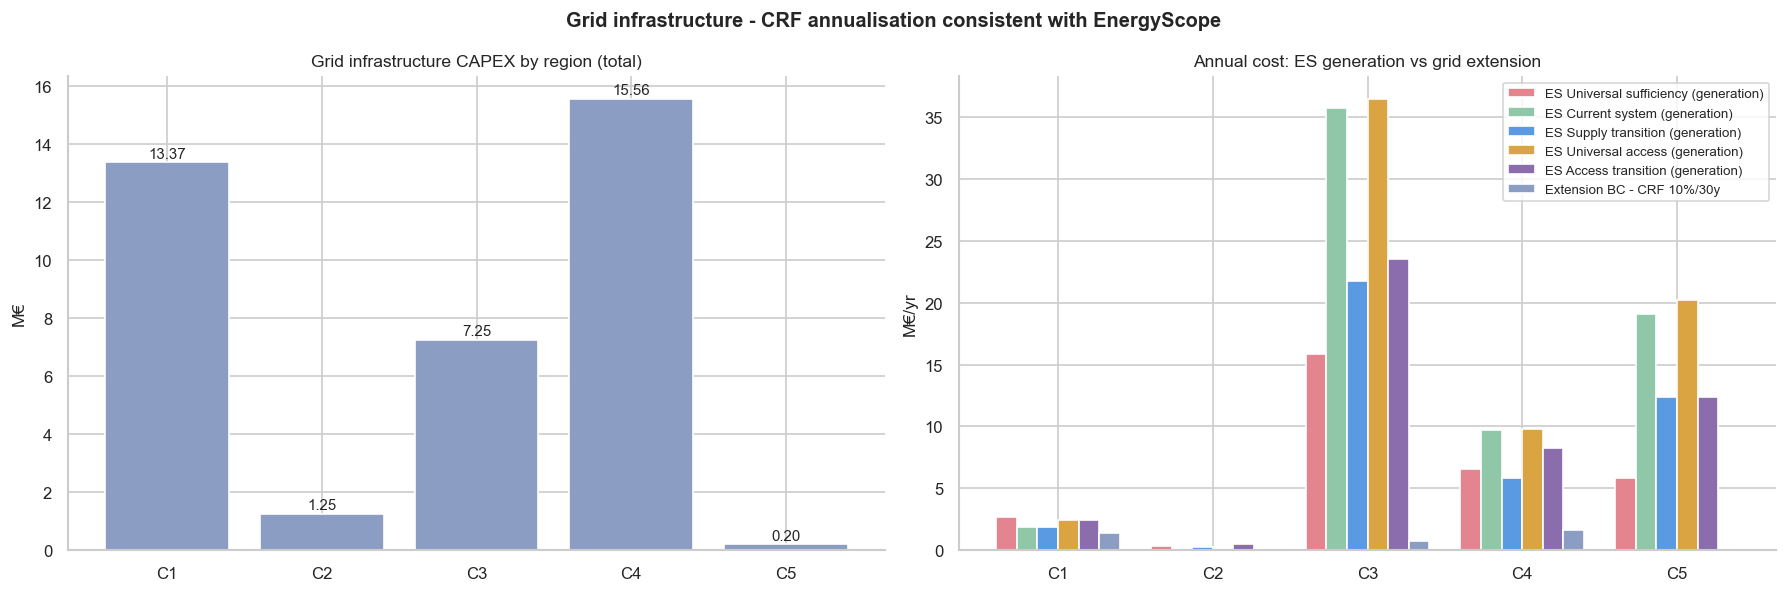


TOTAL SYSTEM COST SUMMARY  (M-euro/year)
                                        Universal sufficiency           Current system        Supply transition         Universal access        Access transition
  Generation (EnergyScope/CPLEX)                       31.275                   66.511                   42.148                   69.016                   47.069
  Grid extension (CRF 10%/30y)                          3.992                    0.000                    0.000                    3.992                    3.992
  TOTAL system cost                                    35.267                   66.511                   42.148                   73.008                   51.060
  Delta  Current system   vs Universal sufficiency : +31.244 M-euro/year  (+88.6 %)
  Delta  Supply transition vs Universal sufficiency : +6.881 M-euro/year  (+19.5 %)
  Delta  Universal access vs Universal sufficiency : +37.741 M-euro/year  (+107.0 %)
  Delta  Access transition vs Universal sufficiency : +15

In [16]:
# Grid extension CAPEX, incremental-tree topology.
# Source: bolivia-energy-data/analyse_GIS_projections/output/2024/cluster_summary.csv
# Method: unit costs from Peña Balderrama et al. (2020), table A.5 - 9000 USD/km of MV line,
#         3500 USD/community (transformer), 150 USD/household (connection), FX 0.924. Each new
#         community connects to the nearest already-connected node.
# Columns: extension_capex_EUR = line + transformer + connection; extension_capex_annualise_EUR
#         = same, annualised upstream with the EnergyScope CRF (i=10%, n=30 years).
# The extension connects dispersed households, so it is charged only to the scenarios that
# achieve universal access (GRID_EXT_SCEN). The per-cluster figures are geographic: the same
# file serves every scenario.
I_RATE   = 0.10
LIFETIME = 30
CRF = I_RATE * (1 + I_RATE)**LIFETIME / ((1 + I_RATE)**LIFETIME - 1)

INFRA_CSV = BOLIVIA_DATA / 'analyse_GIS_projections' / 'output' / '2024' / 'cluster_summary.csv'
assert INFRA_CSV.exists(), (
    f'{INFRA_CSV} not found - bolivia-energy-data is expected next to this repository.')

infra = pd.read_csv(INFRA_CSV)
infra = infra[infra['Cluster'].isin(REGIONS)].set_index('Cluster')   # drops TOTAL

capex_bc   = infra['extension_capex_EUR'] / 1e6             # M€ total CAPEX (tree)
annualized = infra['extension_capex_annualise_EUR'] / 1e6   # M€/yr (CRF 10% / 30y)

# Blocking check against the published tree figures. The topology is the greedy tree with
# mid-span taps: a community may attach to an interior point of an already built edge, creating
# a junction that carries no transformer, no connection and no household.
# 2024 tree: 3 947.91 km, 626 connectable, 71 dispersed.
_tot_eur = infra['extension_capex_EUR'].sum()
_tot_ann = infra['extension_capex_annualise_EUR'].sum()
assert abs(_tot_eur - 37_628_923) <= 1, f'tree CAPEX = {_tot_eur:.0f} EUR, expected 37 628 923'
assert abs(_tot_ann - 3_991_648) <= 1, f'annualised = {_tot_ann:.0f} EUR/yr, expected 3 991 648'

print(f'source: bolivia-energy-data/{INFRA_CSV.relative_to(BOLIVIA_DATA)}')
print(f'CRF({I_RATE:.0%}, {LIFETIME} years) = {CRF:.5f}   (applied upstream)')
print()
print(f'GRID EXTENSION  -  charged to: {", ".join(sorted(GRID_EXT_SCEN))}')
print(f'{"Region":<8} {"CAPEX total (M-euro)":>20} {"Annualised CRF (M-euro/yr)":>26}')
for rg in REGIONS:
    print(f'{rg:<8} {capex_bc.get(rg, 0):>20.3f} {annualized.get(rg, 0):>26.3f}')
print(f'{"TOTAL":<8} {capex_bc.sum():>20.3f} {annualized.sum():>26.3f}')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
x = np.arange(len(REGIONS))

ax = axes[0]
cap = capex_bc.reindex(REGIONS).fillna(0)
bars = ax.bar(x, cap.values, color='#8B9DC3', edgecolor='white')
for b, v in zip(bars, cap.values):
    ax.text(b.get_x() + b.get_width() / 2, v + cap.max() * 0.01, f'{v:.2f}', ha='center', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(REGIONS)
ax.set_ylabel('M€'); ax.set_title('Grid infrastructure CAPEX by region (total)')

ax = axes[1]
infra_ann = annualized.reindex(REGIONS).fillna(0)
gen_cost = {lab: by_region(D, 'cost') for lab, D in DS.items()}
n = len(gen_cost) + 1; w = 0.8 / n
for k, (lab, v) in enumerate(gen_cost.items()):
    ax.bar(x + (k - (n - 1) / 2) * w, v.values, w, color=SCEN_COLORS[lab],
           label=f'ES {lab} (generation)', edgecolor='white')
ax.bar(x + (len(gen_cost) - (n - 1) / 2) * w, infra_ann.values, w, color='#8B9DC3',
       label=f'Extension BC - CRF {I_RATE:.0%}/{LIFETIME}y', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(REGIONS)
ax.set_ylabel('M€/yr'); ax.set_title('Annual cost: ES generation vs grid extension')
ax.legend(fontsize=8)

plt.suptitle('Grid infrastructure - CRF annualisation consistent with EnergyScope', fontweight='bold')
plt.tight_layout(); plt.show()

tot_infra_ann = annualized.sum()
rows = {}
for lab, D in DS.items():
    tc = D['total_cost']
    es_cost = tc[tc['Regions'].isin(REGIONS)]['TotalCost'].sum()
    ext     = tot_infra_ann if lab in GRID_EXT_SCEN else 0.0
    rows[lab] = (es_cost, ext, es_cost + ext)

cw = max(len(lab) for lab in rows) + 4
print()
print('TOTAL SYSTEM COST SUMMARY  (M-euro/year)')
print(f'  {"":34s}' + ''.join(f'{lab:>{cw}}' for lab in rows))
print(f'  {"Generation (EnergyScope/CPLEX)":34s}' + ''.join(f'{v[0]:>{cw}.3f}' for v in rows.values()))
print(f'  {"Grid extension (CRF 10%/30y)":34s}' + ''.join(f'{v[1]:>{cw}.3f}' for v in rows.values()))
print(f'  {"TOTAL system cost":34s}' + ''.join(f'{v[2]:>{cw}.3f}' for v in rows.values()))
ref_tot = rows[SCEN_REF][2]
for lab, v in rows.items():
    if lab == SCEN_REF:
        continue
    d = v[2] - ref_tot
    print(f'  Delta  {lab:<16} vs {SCEN_REF} : {d:+.3f} M-euro/year  ({d / ref_tot * 100:+.1f} %)')


---
## 11. Chapter 5 figures (thesis)  [manuscript figures]

Nine figures for thesis chapter 5. Figures 1-6 compare **Universal sufficiency (US)**, **Current system (CS)** and **Universal access (UA)**; figures 7-9 bring in **Supply transition (ST)** for the full four-scenario comparison, plus a DEC_SOLAR sensitivity run. They are built on the `DS` / `rows` objects already computed in section 10 and reuse the same palette as the rest of the notebook.


In [17]:
import matplotlib.patches as mpatches

# PRINT_RC was set with the dispatch figure of section 8; re-applying it here keeps the two
# blocks in step even when only the chapter-5 cells are re-run.
plt.rcParams.update(PRINT_RC)

CM = 1 / 2.54

# shared by every legend placed inside a gridded plot area
INSET_LEGEND = dict(frameon=True, facecolor='white', edgecolor='none', framealpha=1.0)

US, CS, UA = DS['Universal sufficiency'], DS['Current system'], DS['Universal access']

def stacked_bar(ax, df, order, x, width, seen=None):
    '''Draw one set of stacked bars at positions x using the shared tech palette.'''
    bottom = np.zeros(len(x))
    for key in order:
        if key not in df.columns:
            continue
        vals = df[key].values
        if vals.sum() <= EPS:
            continue
        lab = get_label(key) if (seen is None or key not in seen) else None
        ax.bar(x, vals, width, bottom=bottom, color=get_color(key), edgecolor='white',
               linewidth=0.5, label=lab)
        if seen is not None:
            seen.add(key)
        bottom = bottom + vals
    return bottom

def elec_by_region_tech(yb, techs):
    d = layer(yb, 'ELECTRICITY')
    d = d[d['Elements'].isin(techs) & (d['val'] > EPS) & d['Regions'].isin(REGIONS)]
    return d.pivot_table(index='Regions', columns='Elements', values='val', aggfunc='sum').reindex(REGIONS).fillna(0)

def cost_by_region_tbl(D):
    c = D['cost']; c = c[c['Regions'].isin(REGIONS)]
    return c.groupby('Regions')[['C_inv', 'C_maint', 'C_op']].sum().reindex(REGIONS).fillna(0)

def cost_by_tech_tbl(D):
    c = D['cost']; c = c[c['Regions'].isin(REGIONS)]
    g = c.groupby('Elements')[['C_inv', 'C_maint', 'C_op']].sum()
    g['total'] = g['C_inv'] + g['C_maint']
    return g

def gwp_by_region_tbl(D):
    g = D['gwp']; g = g[g['Regions'].isin(REGIONS)]
    return g.groupby('Regions')[['GWP_op', 'GWP_constr']].sum().reindex(REGIONS).fillna(0)

def import_split(D):
    '''Split the ELECTRICITY resource inflow into true SIN (exterior) import and
    net inter-cluster import, from Resources.csv - Year_balance only carries the
    combined net figure (R_year_exterior + R_year_import - R_year_export).'''
    r = D['res']
    r = r[(r['Resources'] == 'ELECTRICITY') & r['Regions'].isin(REGIONS)].set_index('Regions')
    sin = r['R_year_exterior'].reindex(REGIONS).fillna(0).clip(lower=0)
    # fillna each side BEFORE subtracting: a cluster with zero exports has no
    # R_year_export row at all (NaN), not a 0 - subtracting first turns that
    # NaN into a NaN diff, which fillna(0) then silently zeroes out a real
    # import (e.g. C2: 1.11 GWh import, 0 export -> was wiped to 0).
    imp = r['R_year_import'].reindex(REGIONS).fillna(0)
    exp = r['R_year_export'].reindex(REGIONS).fillna(0)
    inter = (imp - exp).clip(lower=0)
    return pd.DataFrame({'SIN_IMPORT': sin, 'INTERCLUSTER_IMPORT': inter})



### Figure 18 - Electricity production by cluster and technology

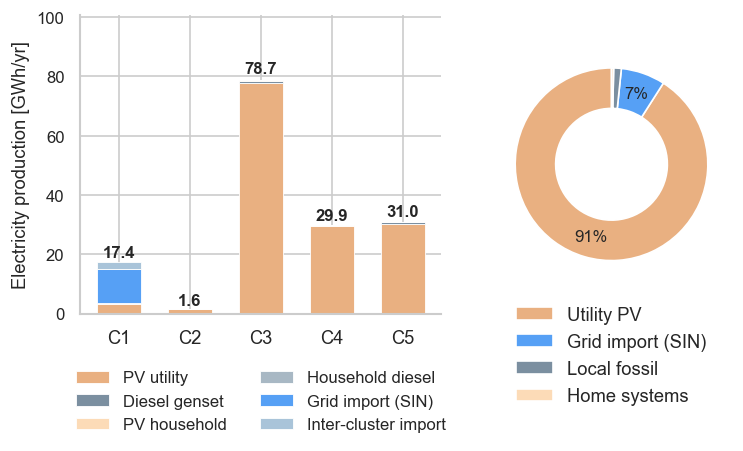

In [18]:
order = ['PV_UTILITY', 'GENSET_DIESEL', 'PV_HS', 'HS_DIESEL', 'SIN_IMPORT', 'INTERCLUSTER_IMPORT']
piv = elec_by_region_tech(US['yb'], ['PV_UTILITY', 'GENSET_DIESEL', 'PV_HS', 'HS_DIESEL'])
piv = pd.concat([piv, import_split(US)], axis=1)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(16 * CM, 10 * CM), gridspec_kw={'width_ratios': [1.5, 1]})

x = np.arange(len(REGIONS))
seen = set()
top = stacked_bar(axL, piv, order, x, 0.62, seen=seen)
for xi, t in zip(x, top):
    axL.text(xi, t + t * 0.015 + 0.3, f'{t:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axL.set_xticks(x); axL.set_xticklabels(REGIONS, fontsize=11)
axL.set_ylabel('Electricity production [GWh/yr]', fontsize=11)
axL.set_ylim(0, top.max() * 1.28)
axL.legend(loc='upper center', bbox_to_anchor=(0.5, -0.14), fontsize=10, ncol=2, frameon=False)

# Primary supply only (production + true exterior import): inter-cluster
# import is excluded, it is already counted as production at the exporting
# cluster and would otherwise be double-counted here.
cat_vals = {
    'Utility PV':        piv.get('PV_UTILITY', pd.Series(dtype=float)).sum(),
    'Grid import (SIN)': piv.get('SIN_IMPORT', pd.Series(dtype=float)).sum(),
    'Local fossil':      piv.get('GENSET_DIESEL', pd.Series(dtype=float)).sum(),
    'Home systems':      piv.get('PV_HS', pd.Series(dtype=float)).sum() + piv.get('HS_DIESEL', pd.Series(dtype=float)).sum(),
}
cat_colors = {'Utility PV': get_color('PV_UTILITY'), 'Grid import (SIN)': get_color('SIN_IMPORT'),
              'Local fossil': get_color('GENSET_DIESEL'), 'Home systems': get_color('PV_HS')}
cat_vals = {k: v for k, v in cat_vals.items() if v > EPS}
wedges, _, _ = axR.pie(cat_vals.values(), colors=[cat_colors[k] for k in cat_vals],
                        autopct=lambda pct: f'{pct:.0f}%' if pct >= 5 else '',
                        startangle=90, pctdistance=0.78,
                        wedgeprops={'width': 0.42, 'edgecolor': 'white'})
axR.legend(wedges, list(cat_vals.keys()), loc='upper center', bbox_to_anchor=(0.5, -0.02), fontsize=11, ncol=1, frameon=False)

plt.tight_layout()
plt.show()


### Figure 20 - Cost decomposition by cluster and main items

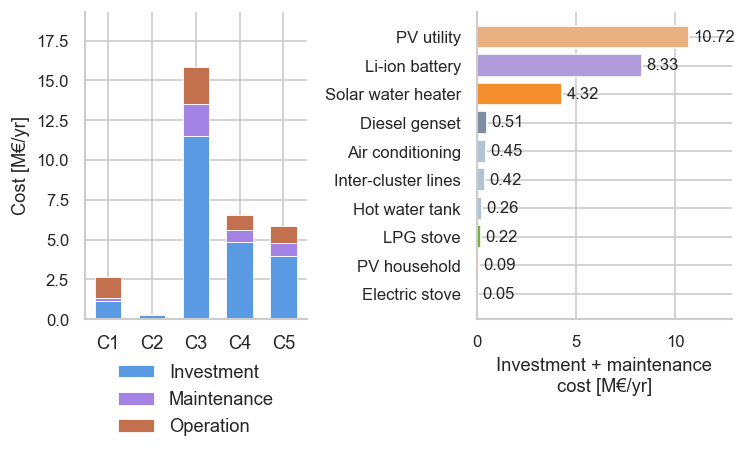

In [19]:
by_reg = cost_by_region_tbl(US)
by_tech = cost_by_tech_tbl(US).sort_values('total', ascending=False).head(10)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(16 * CM, 10 * CM), gridspec_kw={'width_ratios': [1, 1.15]})

x = np.arange(len(REGIONS))
bottom = np.zeros(len(REGIONS))
for col in ['C_inv', 'C_maint', 'C_op']:
    axL.bar(x, by_reg[col].values, 0.6, bottom=bottom, color=COST_COLORS[col],
            label=COST_LABELS[col], edgecolor='white', linewidth=0.5)
    bottom += by_reg[col].values
axL.set_xticks(x); axL.set_xticklabels(REGIONS, fontsize=11)
axL.set_ylabel('Cost [M€/yr]', fontsize=11)
axL.set_ylim(0, bottom.max() * 1.22)
axL.legend(loc='upper center', bbox_to_anchor=(0.5, -0.09), **INSET_LEGEND, fontsize=11)

by_tech = by_tech.iloc[::-1]
y = np.arange(len(by_tech))
axR.barh(y, by_tech['total'].values, color=[get_color(t) for t in by_tech.index], edgecolor='white')
axR.set_yticks(y); axR.set_yticklabels([get_label(t) for t in by_tech.index], fontsize=10)
axR.set_xlim(0, by_tech['total'].max() * 1.2)
for yi, v in zip(y, by_tech['total'].values):
    axR.text(v + by_tech['total'].max() * 0.02, yi, f'{v:.2f}', va='center', fontsize=10)
axR.set_xlabel('Investment + maintenance\ncost [M€/yr]', fontsize=11)

plt.tight_layout()
plt.show()


### Figure 19 - Hot water by technology and cluster

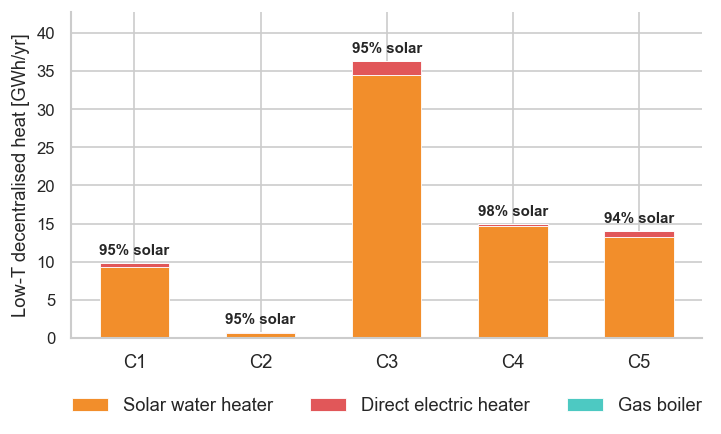

In [20]:
order = ['DEC_SOLAR', 'DEC_DIRECT_ELEC', 'DEC_BOILER_GAS']
d = layer(US['yb'], 'HEAT_LOW_T_DECEN')
d = d[d['Elements'].isin(order) & (d['val'] > EPS) & d['Regions'].isin(REGIONS)]
piv = d.pivot_table(index='Regions', columns='Elements', values='val', aggfunc='sum').reindex(REGIONS).fillna(0)

fig, ax = plt.subplots(figsize=(16 * CM, 9.5 * CM))
x = np.arange(len(REGIONS))
top = stacked_bar(ax, piv, order, x, 0.55)
tot = piv.sum(axis=1)
share_solar = (piv.get('DEC_SOLAR', pd.Series(0, index=REGIONS)) / tot.replace(0, np.nan) * 100).fillna(0)
for xi, t, s in zip(x, top, share_solar.values):
    ax.text(xi, t + max(top) * 0.02, f'{s:.0f}% solar', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(REGIONS, fontsize=11)
ax.set_ylabel('Low-T decentralised heat [GWh/yr]', fontsize=11)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.13), ncol=3, frameon=False, fontsize=11)
ax.set_ylim(0, max(top) * 1.18 if max(top) > 0 else 1)

plt.tight_layout()
plt.show()


### Figure 15 - Current system against universal access, by cluster

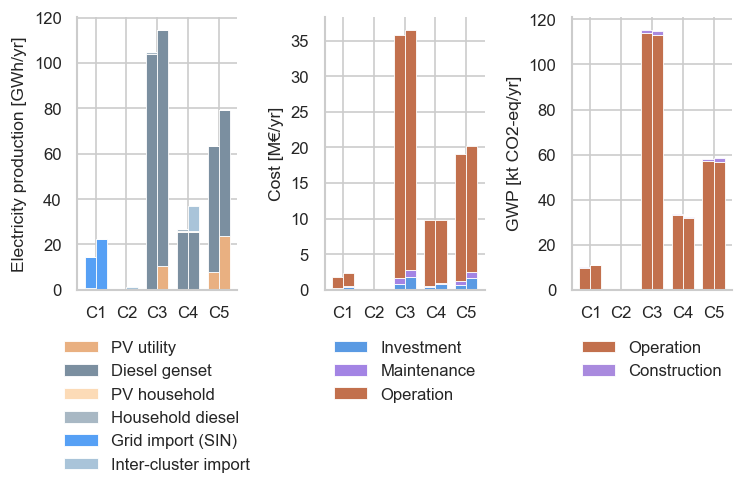

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16 * CM, 11 * CM))
x = np.arange(len(REGIONS))
w = 0.36
order = ['PV_UTILITY', 'GENSET_DIESEL', 'PV_HS', 'HS_DIESEL', 'SIN_IMPORT', 'INTERCLUSTER_IMPORT']

ax = axes[0]
seen = set()
tops = []
for D, dx in [(CS, -w / 2), (UA, w / 2)]:
    piv = elec_by_region_tech(D['yb'], ['PV_UTILITY', 'GENSET_DIESEL', 'PV_HS', 'HS_DIESEL'])
    piv = pd.concat([piv, import_split(D)], axis=1)
    tops.append(stacked_bar(ax, piv, order, x + dx, w, seen=seen))
ax.set_xticks(x); ax.set_xticklabels(REGIONS)
ax.set_ylabel('Electricity production [GWh/yr]')
ax.set_ylim(0, max(t.max() for t in tops) * 1.05)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.13), ncol=1, frameon=False, fontsize=10)

ax = axes[1]
tops = []
for D, dx in [(CS, -w / 2), (UA, w / 2)]:
    by_reg = cost_by_region_tbl(D)
    bottom = np.zeros(len(REGIONS))
    for col in ['C_inv', 'C_maint', 'C_op']:
        lab = COST_LABELS[col] if D is CS else None
        ax.bar(x + dx, by_reg[col].values, w, bottom=bottom, color=COST_COLORS[col],
               edgecolor='white', linewidth=0.5, label=lab)
        bottom += by_reg[col].values
    tops.append(bottom)
ax.set_xticks(x); ax.set_xticklabels(REGIONS)
ax.set_ylabel('Cost [M€/yr]')
ax.set_ylim(0, max(t.max() for t in tops) * 1.05)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.13), ncol=1, frameon=False, fontsize=10)

ax = axes[2]
gwp_order = ['GWP_op', 'GWP_constr']
tops = []
for D, dx in [(CS, -w / 2), (UA, w / 2)]:
    by_reg = gwp_by_region_tbl(D)
    bottom = np.zeros(len(REGIONS))
    for col in gwp_order:
        lab = GWP_LABELS[col] if D is CS else None
        ax.bar(x + dx, by_reg[col].values, w, bottom=bottom, color=GWP_COLORS[col],
               edgecolor='white', linewidth=0.5, label=lab)
        bottom += by_reg[col].values
    tops.append(bottom)
ax.set_xticks(x); ax.set_xticklabels(REGIONS)
ax.set_ylabel('GWP [kt CO2-eq/yr]')
ax.set_ylim(0, max(t.max() for t in tops) * 1.05)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.13), ncol=1, frameon=False, fontsize=10)

plt.tight_layout()
plt.show()


### Home-system production against the dispersed-household target  [complementary, not in the manuscript]

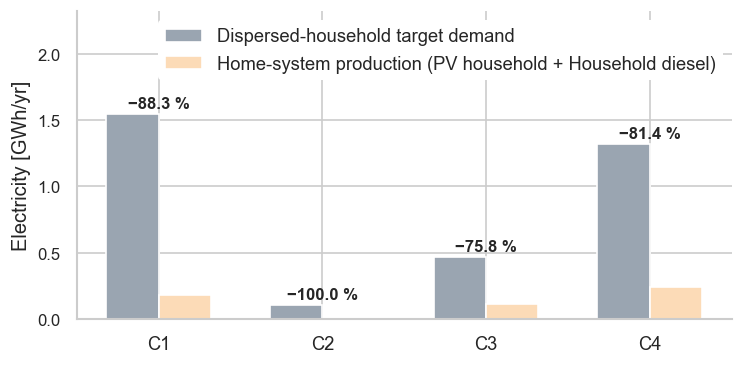

In [22]:
target = {'C1': 1.5479, 'C2': 0.1048, 'C3': 0.4681, 'C4': 1.3209}
regs = list(target.keys())
piv = elec_by_region_tech(UA['yb'], ['PV_HS', 'HS_DIESEL'])
actual = (piv.get('PV_HS', pd.Series(0, index=REGIONS)) + piv.get('HS_DIESEL', pd.Series(0, index=REGIONS)))
actual = actual.reindex(regs).fillna(0)

fig, ax = plt.subplots(figsize=(16 * CM, 8 * CM))
x = np.arange(len(regs)); w = 0.32
ax.bar(x - w / 2, [target[r] for r in regs], w, color='#9AA5B1', edgecolor='white', label='Dispersed-household target demand')
ax.bar(x + w / 2, actual.values, w, color=get_color('PV_HS'), edgecolor='white',
       label=f"Home-system production ({get_label('PV_HS')} + {get_label('HS_DIESEL')})")

ymax = max(max(target.values()), actual.max())
for xi, r in zip(x, regs):
    t, a = target[r], actual[r]
    dev = round((a - t) / t * 100, 1) if t > EPS else 0.0
    sign = '' if dev == 0 else ('+' if dev > 0 else '\u2212')  # avoid "-0.0 %" on a rounded-to-zero deviation
    ax.text(xi, max(t, a) + ymax * 0.03, f'{sign}{abs(dev):.1f} %', ha='center', fontsize=10, fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(regs, fontsize=11)
ax.set_ylabel('Electricity [GWh/yr]', fontsize=12)
ax.set_ylim(0, ymax * 1.50)
ax.legend(loc='best', **INSET_LEGEND, fontsize=11)

plt.tight_layout()
plt.show()


### Figure 16 - Decomposition of the annual cost of universal access

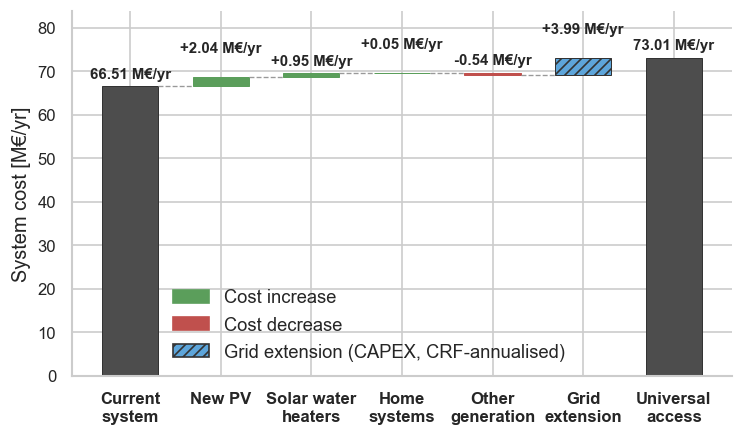

In [23]:
# Reuses `rows` (Current system / Universal access generation + grid-extension
# cost) already computed in section 10's grid-infrastructure cell.
cs_gen, _, _ = rows['Current system']
ua_gen, ua_ext, ua_total = rows['Universal access']

cs_cost_tech = cost_by_tech_tbl(CS)['total']
ua_cost_tech = cost_by_tech_tbl(UA)['total']

def d(tech):
    return ua_cost_tech.get(tech, 0.0) - cs_cost_tech.get(tech, 0.0)

new_pv = d('PV_UTILITY')
solar_wh = d('DEC_SOLAR') + d('TS_DEC_DIRECT_ELEC') + d('DEC_DIRECT_ELEC') + d('DEC_BOILER_GAS')
home_sys = d('PV_HS') + d('HS_DIESEL') + d('BATT_HS')
other_gen = (ua_gen - cs_gen) - new_pv - solar_wh - home_sys
grid_ext = ua_ext

steps = [
    ('Current\nsystem', cs_gen, 'start'),
    ('New PV', new_pv, 'pos'),
    ('Solar water\nheaters', solar_wh, 'pos'),
    ('Home\nsystems', home_sys, 'pos'),
    ('Other\ngeneration', other_gen, 'neg' if other_gen < 0 else 'pos'),
    ('Grid\nextension', grid_ext, 'ext'),
    ('Universal\naccess', cs_gen + new_pv + solar_wh + home_sys + other_gen + grid_ext, 'end'),
]

ymax = cs_gen + new_pv + solar_wh + home_sys + max(other_gen, 0) + grid_ext + max(cs_gen, ua_total) * 0.14

fig, ax = plt.subplots(figsize=(16 * CM, 9.5 * CM))
cum = 0.0
colors = {'start': '#4D4D4D', 'end': '#4D4D4D', 'pos': '#5B9E5B', 'neg': '#C0504D', 'ext': '#5DA5DA'}
for i, (label, val, kind) in enumerate(steps):
    if kind in ('start', 'end'):
        bottom, height = 0, val
        cum = val
    else:
        bottom = cum if val >= 0 else cum + val
        height = abs(val)
        cum += val
    hatch = '////' if kind == 'ext' else None
    # pos/neg steps can be a fraction of a M-euro (e.g. -0.23) on an axis
    # spanning tens of M-euro: a 0.6pt dark edge on a ~1px-tall bar swallows
    # the fill colour entirely, so 'Cost decrease' never actually reads red.
    # Match the edge to the fill for those bars instead.
    edge = colors[kind] if kind in ('pos', 'neg') else '#333333'
    ax.bar(i, height, bottom=bottom, width=0.62, color=colors[kind],
           edgecolor=edge, linewidth=0.6, hatch=hatch)
    label_y = bottom + height + ymax * (0.015 + 0.045 * (i % 2))
    txt = f'{val:+.2f}' if kind not in ('start', 'end') else f'{val:.2f}'
    ax.text(i, label_y, f'{txt} M€/yr', ha='center', va='bottom', fontsize=9, fontweight='bold')

cum_track, run = [], 0.0
for label, val, kind in steps:
    if kind == 'start':
        run = val
    elif kind != 'end':
        run += val
    cum_track.append(run)
for i in range(len(steps) - 2):
    ax.plot([i + 0.31, i + 1 - 0.31], [cum_track[i], cum_track[i]], color='#999999', lw=0.8, ls='--')

ax.set_xticks(range(len(steps))); ax.set_xticklabels([s[0] for s in steps], fontsize=10, fontweight='bold')
ax.set_ylabel('System cost [M€/yr]', fontsize=12)
ax.set_ylim(0, ymax)

legend_handles = [
    mpatches.Patch(color=colors['pos'], label='Cost increase'),
    mpatches.Patch(color=colors['neg'], label='Cost decrease'),
    mpatches.Patch(facecolor=colors['ext'], hatch='////', edgecolor='#333333', label='Grid extension (CAPEX, CRF-annualised)'),
]
ax.legend(handles=legend_handles, loc='lower center', bbox_to_anchor=(0.45, -0.005), frameon=False, fontsize=11)

plt.tight_layout()
plt.show()


### Figure 24 - The five scenarios compared, annual cost

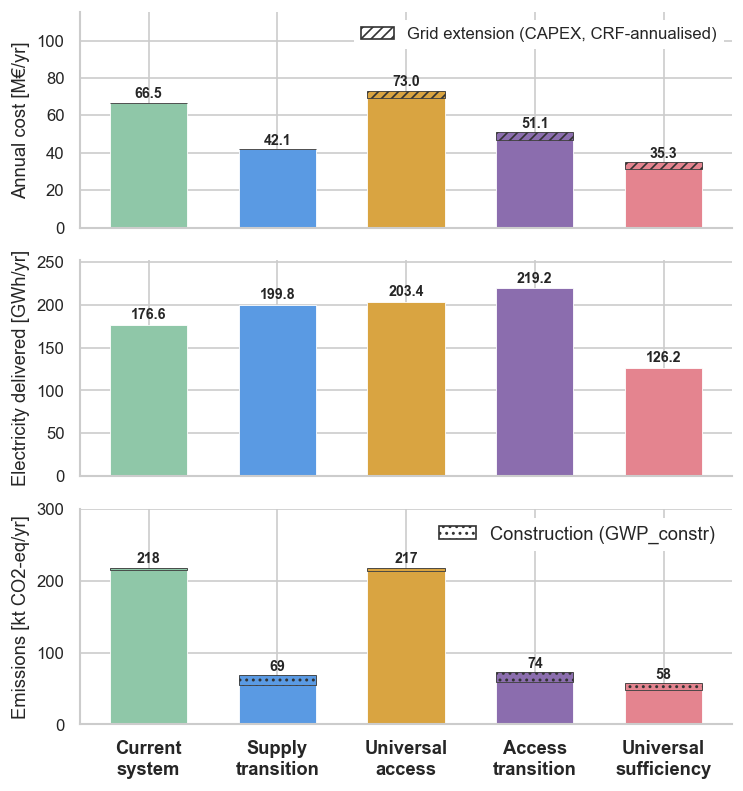

In [24]:
SCEN_ORDER = ['Current system', 'Supply transition', 'Universal access', 'Access transition', 'Universal sufficiency']
SCEN_XLABELS = {'Current system': 'Current\nsystem', 'Supply transition': 'Supply\ntransition',
                'Universal access': 'Universal\naccess', 'Access transition': 'Access\ntransition',
                'Universal sufficiency': 'Universal\nsufficiency'}
SCEN_DATADIR = {'Current system': DATA / 'reality', 'Supply transition': DATA / 'reality',
                'Universal access': DATA / 'reality_access', 'Access transition': DATA / 'reality_access',
                'Universal sufficiency': DATA / 'sufficiency'}

def elec_tech_consumption(yb, data_dir):
    '''Electricity annually consumed by non-storage end-use technologies, identified
    from their negative ELECTRICITY coefficient in Layers_in_out.csv.'''
    lio = pd.read_csv(Path(data_dir) / '00_INDEP' / 'Layers_in_out.csv', sep=';', index_col=0)
    consumers = lio[lio['ELECTRICITY'] < 0].index
    d = layer(yb, 'ELECTRICITY')
    d = d[d['Regions'].isin(REGIONS) & d['Elements'].isin(consumers) &
          (~d['Elements'].isin(STORAGE_TECHS)) & (d['val'] < -EPS)]
    return -d['val'].sum()

def elec_direct_demand(data_dir):
    '''Direct electricity useful demand: the ELECTRICITY line of Demands.csv
    (all sectors, all clusters) - end-uses met without an explicit conversion tech.'''
    tot = 0.0
    for r in REGIONS:
        dm = pd.read_csv(Path(data_dir) / r / 'Demands.csv', sep=';')
        row = dm[dm['parameter name'] == 'ELECTRICITY']
        cols = [c for c in dm.columns if c not in ('Category', 'Subcategory', 'parameter name', 'Units')]
        tot += row[cols].apply(pd.to_numeric, errors='coerce').sum(axis=1).sum()
    return tot

def elec_delivered(yb, data_dir):
    '''Electricity delivered to final uses = end-use tech consumption + direct demand.'''
    return elec_tech_consumption(yb, data_dir) + elec_direct_demand(data_dir)

gen_cost   = {lab: rows[lab][0] for lab in SCEN_ORDER}
ext_cost   = {lab: rows[lab][1] for lab in SCEN_ORDER}
tot_cost   = {lab: rows[lab][2] for lab in SCEN_ORDER}
elec_deliv = {lab: elec_delivered(DS[lab]['yb'], SCEN_DATADIR[lab]) for lab in SCEN_ORDER}
gwp_tot    = {lab: gwp_by_region_tbl(DS[lab]).sum() for lab in SCEN_ORDER}   # Series: GWP_op, GWP_constr

fig, axes = plt.subplots(3, 1, figsize=(16 * CM, 17 * CM), sharex=True)
x = np.arange(len(SCEN_ORDER))

ax = axes[0]
for xi, lab in zip(x, SCEN_ORDER):
    ax.bar(xi, gen_cost[lab], 0.6, color=SCEN_COLORS[lab], edgecolor='white', linewidth=0.5)
    ax.bar(xi, ext_cost[lab], 0.6, bottom=gen_cost[lab], color=SCEN_COLORS[lab],
           edgecolor='#333333', linewidth=0.5, hatch='////')
    tot = gen_cost[lab] + ext_cost[lab]
    ax.text(xi, tot + tot * 0.015, f'{tot:.1f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
ax.set_ylabel('Annual cost [M€/yr]', fontsize=11)
ax.set_ylim(0, max(tot_cost.values()) * 1.58)
ext_patch = mpatches.Patch(facecolor='white', edgecolor='#333333', hatch='////', label='Grid extension (CAPEX, CRF-annualised)')
ax.legend(handles=[ext_patch], loc='upper right', **INSET_LEGEND, fontsize=10)

ax = axes[1]
v = [elec_deliv[l] for l in SCEN_ORDER]
ax.bar(x, v, 0.6, color=[SCEN_COLORS[l] for l in SCEN_ORDER], edgecolor='white', linewidth=0.5)
for xi, val in zip(x, v):
    ax.text(xi, val + max(v) * 0.015, f'{val:.1f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
ax.set_ylabel('Electricity delivered [GWh/yr]', fontsize=11)
ax.set_ylim(0, max(v) * 1.15)

ax = axes[2]
for xi, lab in zip(x, SCEN_ORDER):
    op, co = gwp_tot[lab]['GWP_op'], gwp_tot[lab]['GWP_constr']
    ax.bar(xi, op, 0.6, color=SCEN_COLORS[lab], edgecolor='white', linewidth=0.5)
    ax.bar(xi, co, 0.6, bottom=op, color=SCEN_COLORS[lab], edgecolor='#333333', linewidth=0.5, hatch='...')
    ax.text(xi, op + co + (op + co) * 0.015, f'{op + co:.0f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
ax.set_ylabel('Emissions [kt CO2-eq/yr]', fontsize=11)
ax.set_ylim(0, max(v['GWP_op'] + v['GWP_constr'] for v in gwp_tot.values()) * 1.38)
constr_patch = mpatches.Patch(facecolor='white', edgecolor='#333333', hatch='...', label='Construction (GWP_constr)')
ax.legend(handles=[constr_patch], loc='upper right', **INSET_LEGEND, fontsize=11)

# The five scenario names are written once, under the bottom panel: a 16 cm axis leaves
# 3.2 cm per name, enough for the two-line labels at full size without rotation.
axes[-1].set_xticks(x)
axes[-1].set_xticklabels([SCEN_XLABELS[l] for l in SCEN_ORDER], fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


### Figure 25 - Annual cost against emissions, five scenarios

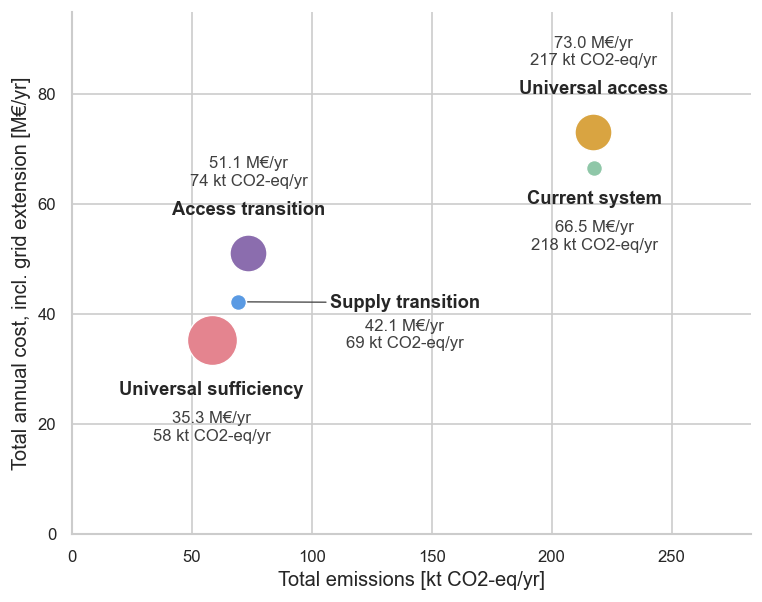

In [25]:
# Households connected at a sufficiency consumption level: the target demand used to size the
# universal-coverage scenarios (figure 5).
HOUSEHOLDS_SUFF = {'Current system': 0, 'Supply transition': 0,
                    'Universal access': 20714, 'Access transition': 20714,
                    'Universal sufficiency': 84209}
MARKER_MIN, MARKER_MAX = 90, 900

def marker_size(n):
    if n <= 0:
        return MARKER_MIN
    return MARKER_MIN + (MARKER_MAX - MARKER_MIN) * (n / max(HOUSEHOLDS_SUFF.values())) ** 0.5

emissions = {lab: gwp_tot[lab]['GWP_op'] + gwp_tot[lab]['GWP_constr'] for lab in SCEN_ORDER}

fig, ax = plt.subplots(figsize=(16.4 * CM, 13 * CM))

# Current system sits almost directly below Universal access (same emissions,
# lower cost), and Supply transition almost directly above Universal
# sufficiency: push each point's labels to the opposite side of its neighbour
# (above/below) so the two never collide, then push the value line further out
# still, past the scenario-name line, on that same side.
# Access transition sits close to Supply transition (emissions 75 vs 69, cost
# 52.6 vs 42.3): nothing else sits directly above Access transition, so it
# uses the plain above/below mechanism like every other point.
# Supply transition itself is boxed in: Universal sufficiency's marker sits
# almost touching it below-left, and Access transition's marker sits close
# above-right, so there is no free spot next to its own marker. Its label is
# placed further out (down-right) with a thin leader line back to the point.
label_above = {'Current system': False, 'Universal access': True,
                'Universal sufficiency': False, 'Access transition': True}

for lab in SCEN_ORDER:
    s = marker_size(HOUSEHOLDS_SUFF[lab])
    r = (s / np.pi) ** 0.5  # marker radius in points, to clear it with the labels
    ax.scatter(emissions[lab], tot_cost[lab], s=s, color=SCEN_COLORS[lab],
               edgecolor='white', linewidth=0.8, zorder=3)
    if lab == 'Supply transition':
        ax.annotate(lab, (emissions[lab], tot_cost[lab]), xytext=(r + 50, +5),
                    textcoords='offset points', ha='left', va='top', fontsize=11, fontweight='bold',
                    arrowprops=dict(arrowstyle='-', color="#3D3D3D", lw=0.75, shrinkA=0, shrinkB=6))
        ax.annotate(f'{tot_cost[lab]:.1f} M€/yr\n{emissions[lab]:.0f} kt CO2-eq/yr',
                    (emissions[lab], tot_cost[lab]), xytext=(r + 95, -10),
                    textcoords='offset points', ha='center', va='top', fontsize=10, color='#404040')
        continue
    sign = 1 if label_above[lab] else -1
    va = 'bottom' if label_above[lab] else 'top'
    ax.annotate(lab, (emissions[lab], tot_cost[lab]), xytext=(0, sign * (r + 8)),
                textcoords='offset points', ha='center', va=va, fontsize=11, fontweight='bold')
    ax.annotate(f'{tot_cost[lab]:.1f} M€/yr\n{emissions[lab]:.0f} kt CO2-eq/yr',
                (emissions[lab], tot_cost[lab]), xytext=(0, sign * (r + 26)),
                textcoords='offset points', ha='center', va=va, fontsize=10, color="#404040")

ax.set_xlabel('Total emissions [kt CO2-eq/yr]', fontsize=12)
ax.set_ylabel('Total annual cost, incl. grid extension [M€/yr]', fontsize=12)
ax.set_xlim(0, max(emissions.values()) * 1.3)
ax.set_ylim(0, max(tot_cost.values()) * 1.3)

plt.tight_layout()
plt.show()


### Figure 21 - Effect of blocking the solar water heater

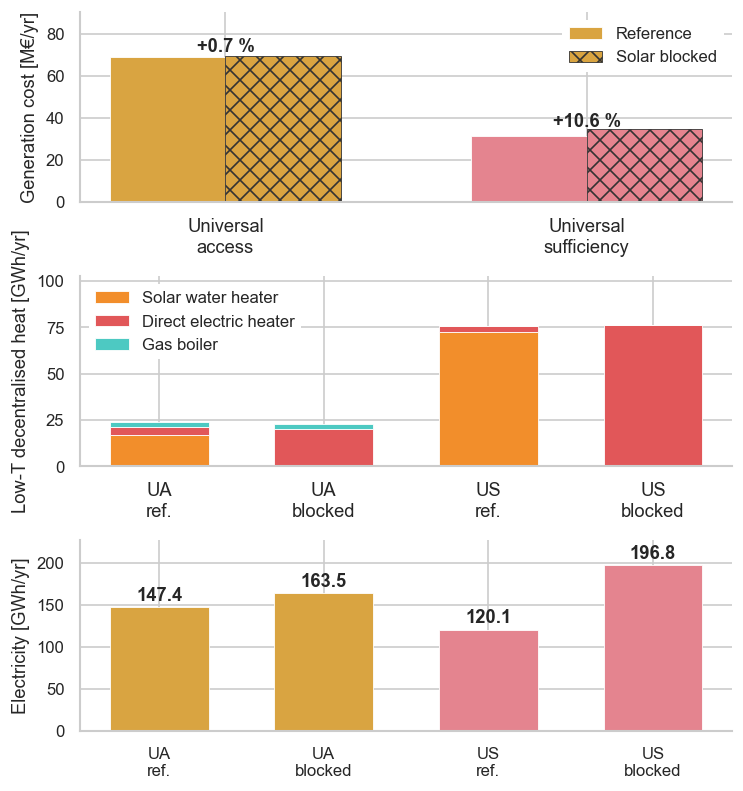

In [26]:
# DEC_SOLAR (solar water heater) forced to f_max = 0, Universal access & Universal
# sufficiency only - isolates how much of the hot-water / cost outcome relies on it.
SENS_ROOT = ROOT / '_sensitivity_DEC_SOLAR_fmax0'
SENS_CASES = ['UA ref', 'UA blocked', 'US ref', 'US blocked']
SENS_XLABELS = {'UA ref': 'UA\nref.', 'UA blocked': 'UA\nblocked',
                'US ref': 'US\nref.', 'US blocked': 'US\nblocked'}
SENS_BASE = {
    'UA ref':     ROOT / 'norte_amazonia_reality_access_2025' / 'outputs',
    'UA blocked': SENS_ROOT / 'reality_access' / 'outputs',
    'US ref':     ROOT / 'norte_amazonia_sufficiency_2025' / 'outputs',
    'US blocked': SENS_ROOT / 'sufficiency' / 'outputs',
}
SENS_DATADIR = {'UA ref': DATA / 'reality_access', 'UA blocked': DATA / 'reality_access',
                 'US ref': DATA / 'sufficiency', 'US blocked': DATA / 'sufficiency'}
SENS_COLORS = {'UA ref': SCEN_COLORS['Universal access'], 'UA blocked': SCEN_COLORS['Universal access'],
               'US ref': SCEN_COLORS['Universal sufficiency'], 'US blocked': SCEN_COLORS['Universal sufficiency']}

SENS = {lab: load_scenario(base) for lab, base in SENS_BASE.items()}
for lab, D in SENS.items():
    si = D['solve']
    status = float(si[si.iloc[:, 0].astype(str).str.contains('solve_result_num', na=False)].iloc[0, 1])
    assert status == 0, f'{lab}: solve_result_num = {status} (not optimal) - do not trust this run'

sens_cost = {lab: D['total_cost'][D['total_cost']['Regions'].isin(REGIONS)]['TotalCost'].sum()
             for lab, D in SENS.items()}
sens_elec = {lab: elec_tech_consumption(D['yb'], SENS_DATADIR[lab]) for lab, D in SENS.items()}

hw_order = ['DEC_SOLAR', 'DEC_DIRECT_ELEC', 'DEC_BOILER_GAS']
hw = {}
for lab, D in SENS.items():
    d = layer(D['yb'], 'HEAT_LOW_T_DECEN')
    d = d[d['Elements'].isin(hw_order) & (d['val'] > EPS) & d['Regions'].isin(REGIONS)]
    hw[lab] = d.groupby('Elements')['val'].sum().reindex(hw_order).fillna(0)

fig, axes = plt.subplots(3, 1, figsize=(16 * CM, 17 * CM))

ax = axes[0]
groups = ['UA', 'US']
xg = np.arange(len(groups)); w = 0.32
for i, grp in enumerate(groups):
    ref_v, blk_v = sens_cost[f'{grp} ref'], sens_cost[f'{grp} blocked']
    ax.bar(xg[i] - w / 2, ref_v, w, color=SENS_COLORS[f'{grp} ref'], edgecolor='white',
           linewidth=0.5, label='Reference' if i == 0 else None)
    ax.bar(xg[i] + w / 2, blk_v, w, color=SENS_COLORS[f'{grp} blocked'], edgecolor='#333333',
           linewidth=0.5, hatch='xx', label='Solar blocked' if i == 0 else None)
    gap = (blk_v - ref_v) / ref_v * 100
    ax.text(xg[i], max(ref_v, blk_v) * 1.03, f'{gap:+.1f} %', ha='center', fontsize=11, fontweight='bold')
ax.set_xticks(xg); ax.set_xticklabels(['Universal\naccess', 'Universal\nsufficiency'], fontsize=11)
ax.set_ylabel('Generation cost [M€/yr]', fontsize=11)
ax.set_ylim(0, max(sens_cost.values()) * 1.30)
ax.legend(loc='upper right', **INSET_LEGEND, fontsize=10)

ax = axes[1]
x2 = np.arange(len(SENS_CASES))
bottom = np.zeros(len(SENS_CASES))
for tech in hw_order:
    vals = np.array([hw[lab][tech] for lab in SENS_CASES])
    ax.bar(x2, vals, 0.6, bottom=bottom, color=get_color(tech), edgecolor='white',
           linewidth=0.5, label=get_label(tech))
    bottom += vals
ax.set_xticks(x2); ax.set_xticklabels([SENS_XLABELS[l] for l in SENS_CASES], fontsize=11)
ax.set_ylabel('Low-T decentralised heat [GWh/yr]', fontsize=11)
ax.set_ylim(0, bottom.max() * 1.35)
ax.legend(loc='upper left', ncol=1, **INSET_LEGEND, fontsize=10)

ax = axes[2]
v3 = [sens_elec[lab] for lab in SENS_CASES]
ax.bar(x2, v3, 0.6, color=[SENS_COLORS[l] for l in SENS_CASES], edgecolor='white', linewidth=0.5)
for xi, val in zip(x2, v3):
    ax.text(xi, val + max(v3) * 0.015, f'{val:.1f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_xticks(x2); ax.set_xticklabels([SENS_XLABELS[l] for l in SENS_CASES])
ax.set_ylabel('Electricity [GWh/yr]', fontsize=11)
ax.set_ylim(0, max(v3) * 1.15)

plt.tight_layout()
plt.show()


---
## 12. Cost waterfall and the remaining manuscript figures  [manuscript figures]

Three-step decomposition of the 2025 generation cost: rebuilding the supply, then the two
moves that bring every source to the household bundle.


### Figure 23 - The three steps from the current system to universal sufficiency

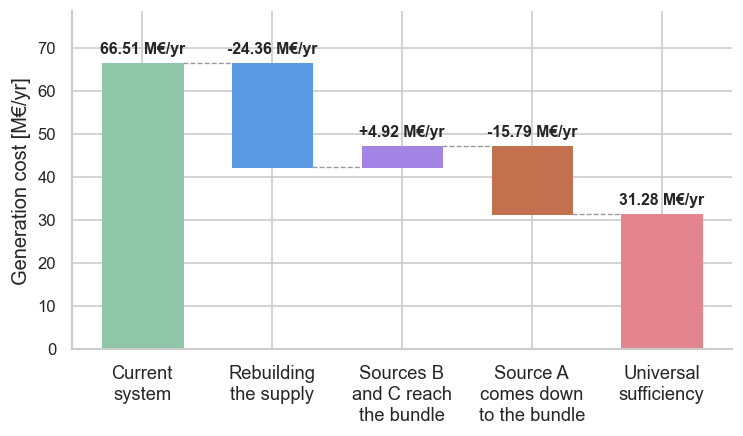

In [27]:
START = 66.51
STEPS = [
    ('Rebuilding\nthe supply',              -24.36),
    ('Sources B\nand C reach\nthe bundle',    4.92),
    ('Source A\ncomes down\nto the bundle', -15.79),
]
END = START + sum(v for _, v in STEPS)

bars = ([('Current\nsystem', START, SCEN_COLORS['Current system'])]
        + [(lab, val, col) for (lab, val), col in zip(STEPS, COST_COLORS.values())]
        + [('Universal\nsufficiency', END, SCEN_COLORS['Universal sufficiency'])])
ymax = START * 1.18

fig, ax = plt.subplots(figsize=(16 * CM, 9.5 * CM))
cum, levels = 0.0, []
for i, (lab, val, color) in enumerate(bars):
    anchored = i in (0, len(bars) - 1)                 # endpoints rest on the axis
    bottom = 0.0 if anchored else min(cum, cum + val)
    height = val if anchored else abs(val)
    cum = val if anchored else cum + val
    levels.append(cum)
    ax.bar(i, height, 0.62, bottom=bottom, color=color, edgecolor=color, linewidth=0.6)
    txt = f'{val:.2f}' if anchored else f'{val:+.2f}'
    ax.text(i, bottom + height + ymax * 0.02, f'{txt} M\u20ac/yr',
            ha='center', va='bottom', fontsize=9.5, fontweight='bold')

for i in range(len(bars) - 1):
    ax.plot([i + 0.31, i + 0.69], [levels[i]] * 2, color='#999999', lw=0.8, ls='--')

ax.set_xticks(range(len(bars)))
ax.set_xticklabels([b[0] for b in bars], fontsize=11)
ax.set_ylabel('Generation cost [M\u20ac/yr]', fontsize=12)
ax.set_ylim(0, ymax)

plt.tight_layout()
plt.show()


### Figure 22 - Annual electricity production, five 2025 scenarios

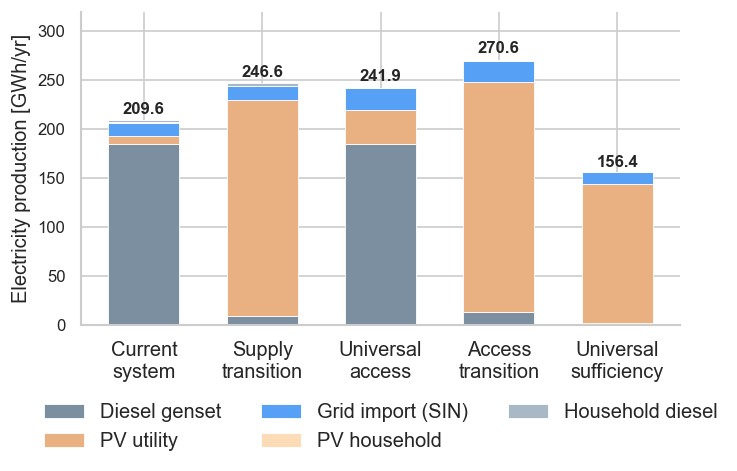

Total electricity production by scenario [GWh/yr]:
  Current system           209.56
  Supply transition        246.64
  Universal access         241.95
  Access transition        270.62
  Universal sufficiency    156.36


In [28]:
MIX_TECHS = ['GENSET_DIESEL', 'PV_UTILITY', 'PV_HS', 'HS_DIESEL']
MIX_ORDER = ['GENSET_DIESEL', 'PV_UTILITY', 'SIN_IMPORT', 'PV_HS', 'HS_DIESEL']

def elec_mix_totals(lab):
    '''Total annual electricity production per technology (all clusters), GWh/yr.'''
    d = DS[lab]
    tot = elec_by_region_tech(d['yb'], MIX_TECHS).sum()
    tot['SIN_IMPORT'] = import_split(d)['SIN_IMPORT'].sum()
    return tot

mix = (pd.DataFrame({lab: elec_mix_totals(lab) for lab in SCEN_ORDER})
       .T.reindex(index=SCEN_ORDER, columns=MIX_ORDER).fillna(0))

fig, ax = plt.subplots(figsize=(16 * CM, 10.5 * CM))
x = np.arange(len(SCEN_ORDER))
totals = stacked_bar(ax, mix, MIX_ORDER, x, 0.6)
for xi, tot in zip(x, totals):
    ax.text(xi, tot + tot * 0.015, f'{tot:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([SCEN_XLABELS[l] for l in SCEN_ORDER], rotation=0, ha='center', fontsize=12)
ax.set_ylabel('Electricity production [GWh/yr]', fontsize=12)
ax.set_ylim(0, max(totals) * 1.18)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.19), ncol=3, fontsize=12, frameon=False)

plt.tight_layout()
plt.show()

print('Total electricity production by scenario [GWh/yr]:')
for lab, tot in zip(SCEN_ORDER, totals):
    print(f'  {lab:22s} {tot:8.2f}')

### Figure 35 - BNA households by electricity source, 2024 census

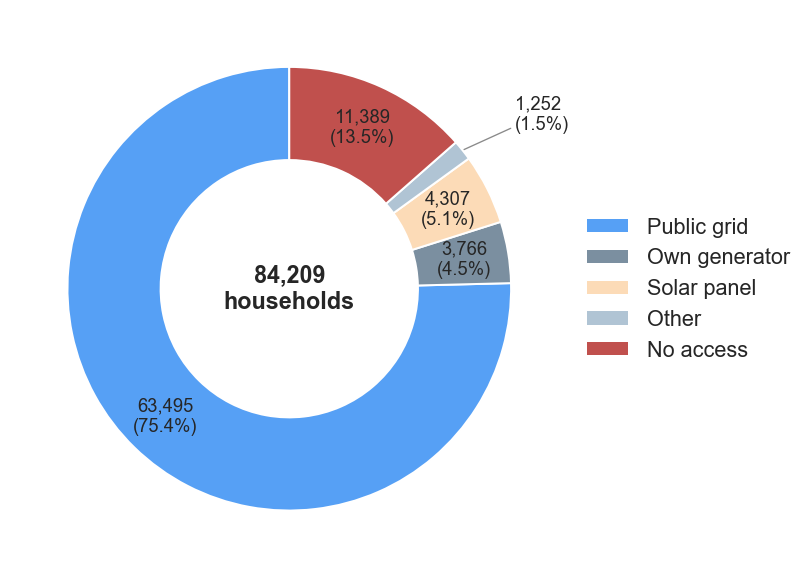

Households by electricity source (total 84,209):
  Public grid      63,495  ( 75.4%)
  Own generator     3,766  (  4.5%)
  Solar panel       4,307  (  5.1%)
  Other             1,252  (  1.5%)
  No access        11,389  ( 13.5%)


In [29]:
HH_SOURCE = {'Public grid': 63495, 'Own generator': 3766, 'Solar panel': 4307,
             'Other': 1252, 'No access': 11389}
HH_COLORS = {'Public grid': get_color('SIN_IMPORT'), 'Own generator': get_color('GENSET_DIESEL'),
             'Solar panel': get_color('PV_HS'), 'Other': '#B0C4D4', 'No access': '#C0504D'}
hh_total = sum(HH_SOURCE.values())
labels = list(HH_SOURCE.keys())
values = [HH_SOURCE[l] for l in labels]
colors = [HH_COLORS[l] for l in labels]

SMALL_PCT = 3.0   # below this a wedge is too thin to hold its label: it goes outside

def hh_label(n, pct):
    return f'{n:,}\n({pct:.1f}%)'

def hh_autopct(pct):
    return '' if pct < SMALL_PCT else hh_label(round(pct / 100 * hh_total), pct)

fig, ax = plt.subplots(figsize=(17 * CM, 12.5 * CM))
wedges, _, _ = ax.pie(values, colors=colors, startangle=90, pctdistance=0.80,
                       autopct=hh_autopct, wedgeprops={'width': 0.42, 'edgecolor': 'white', 'linewidth': 1.2},
                       textprops={'fontsize': 11})
# Leader lines for the wedges whose label did not fit inside them.
for w, lab in zip(wedges, labels):
    pct = HH_SOURCE[lab] / hh_total * 100
    if pct >= SMALL_PCT:
        continue
    ang = np.deg2rad((w.theta1 + w.theta2) / 2)
    x, y = np.cos(ang), np.sin(ang)
    ax.annotate(hh_label(HH_SOURCE[lab], pct),
                xy=(x, y), xytext=(1.30 * x, 1.26 * y),
                ha='left' if x >= 0 else 'right', va='center', fontsize=11,
                arrowprops=dict(arrowstyle='-', color='#8A8A8A', lw=0.8, shrinkA=0, shrinkB=1))

ax.text(0, 0, f'{hh_total:,}\nhouseholds', ha='center', va='center', fontsize=14, fontweight='bold')
ax.legend(wedges, labels, loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=13, frameon=False)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

print(f'Households by electricity source (total {hh_total:,}):')
for l in labels:
    print(f'  {l:15s} {HH_SOURCE[l]:>7,}  ({HH_SOURCE[l] / hh_total * 100:5.1f}%)')

### Figure 33 - Deviation of the predicted 2024 population from the census, six models

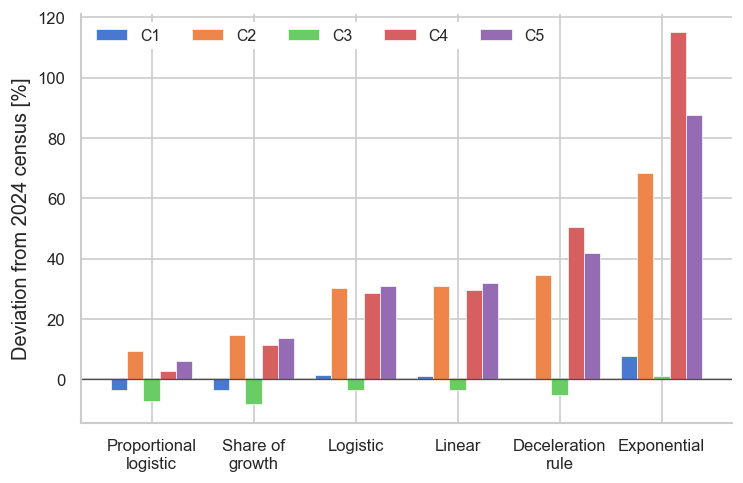

source: bolivia-energy-data/projections\output\backtest_clusters_2024.csv
               logistique_proportionnel  share_of_growth  logistique  lineaire   rho  exponentiel
cluster_label                                                                                    
C1                                 -3.6             -3.7         1.4       1.2   0.1          7.6
C2                                  9.4             14.7        30.4      31.0  34.5         68.2
C3                                 -7.2             -8.2        -3.6      -3.5  -5.3          1.0
C4                                  2.9             11.5        28.5      29.6  50.3        115.0
C5                                  5.9             13.7        31.0      31.8  41.9         87.7


In [30]:
# The six rows come straight from the projection notebook's own export, so this figure cannot
# drift from the table it reports: bolivia-energy-data/projections/02_population_2035_2050.ipynb
# writes backtest_clusters_2024.csv. The column order in that file is the model ranking
# (increasing mean APE), which is the left-to-right order here.
import textwrap

BACKTEST_CSV = BOLIVIA_DATA / 'projections' / 'output' / 'backtest_clusters_2024.csv'
assert BACKTEST_CSV.exists(), (
    f'{BACKTEST_CSV} not found - re-run 02_population_2035_2050.ipynb in '
    'bolivia-energy-data, it writes this file at the six-model cluster table.')

MODEL_LABELS = {   # column name in the projection notebook -> label drawn on this figure
    'logistique_proportionnel': 'Proportional logistic',
    'share_of_growth':          'Share of growth',
    'logistique':               'Logistic',
    'lineaire':                 'Linear',
    'rho':                      'Deceleration rule',
    'exponentiel':              'Exponential',
}

bt = pd.read_csv(BACKTEST_CSV, index_col='cluster_label').reindex(REGIONS)
unknown = [c for c in bt.columns if c not in MODEL_LABELS]
assert not unknown, f'model column(s) with no display name in {BACKTEST_CSV.name}: {unknown}'
absent = bt.index[bt.isna().any(axis=1)].tolist()
assert not absent, f'cluster(s) missing from {BACKTEST_CSV.name}: {absent}'

BACKTEST = {MODEL_LABELS[c]: bt[c].tolist() for c in bt.columns}
# Two-line wrap at the width the 16 cm axis affords, derived rather than hand-written so
# that a renamed model does not silently produce an overlapping tick label.
BACKTEST_XLABELS = {m: textwrap.fill(m, 13) for m in BACKTEST}
models = list(BACKTEST.keys())
cluster_colors = sns.color_palette('muted', len(REGIONS))

fig, ax = plt.subplots(figsize=(16 * CM, 10.5 * CM))
x = np.arange(len(models))
w = 0.8 / len(REGIONS)
for i, (reg, col) in enumerate(zip(REGIONS, cluster_colors)):
    vals = [BACKTEST[m][i] for m in models]
    ax.bar(x + (i - (len(REGIONS) - 1) / 2) * w, vals, w, color=col, edgecolor='white',
           linewidth=0.4, label=reg)
ax.axhline(0, color='#4D4D4D', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels([BACKTEST_XLABELS[m] for m in models], fontsize=10)
ax.set_ylabel('Deviation from 2024 census [%]', fontsize=12)
ax.legend(loc='upper left', ncol=5, **INSET_LEGEND)

plt.tight_layout()
plt.show()

print(f'source: bolivia-energy-data/{BACKTEST_CSV.relative_to(BOLIVIA_DATA)}')
print(bt.to_string())

### Figure 29 - Normalised weights of the twelve clustering variables

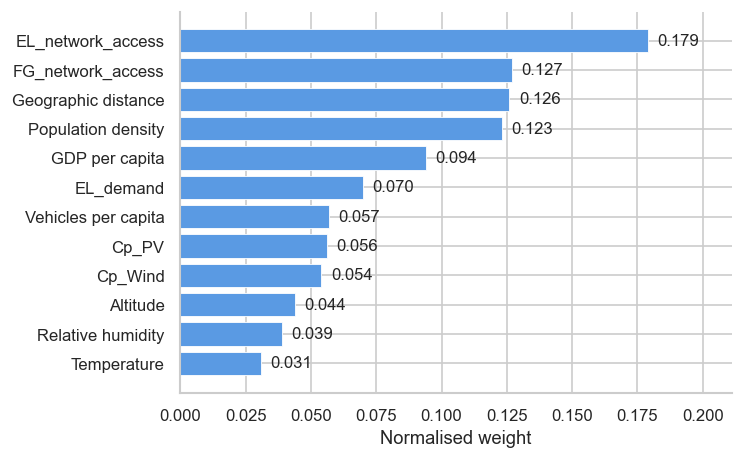

In [31]:
CLUSTER_WEIGHTS = {
    'EL_network_access': 0.179, 'FG_network_access': 0.127, 'Geographic distance': 0.126,
    'Population density': 0.123, 'GDP per capita': 0.094, 'EL_demand': 0.070,
    'Vehicles per capita': 0.057, 'Cp_PV': 0.056, 'Cp_Wind': 0.054,
    'Altitude': 0.044, 'Relative humidity': 0.039, 'Temperature': 0.031,
}
cw = pd.Series(CLUSTER_WEIGHTS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(16 * CM, 10 * CM))
y = np.arange(len(cw))
ax.barh(y, cw.values, color='#5A9AE3', edgecolor='white', linewidth=0.5)
ax.set_yticks(y); ax.set_yticklabels(cw.index)
for yi, v in zip(y, cw.values):
    ax.text(v + cw.max() * 0.02, yi, f'{v:.3f}', va='center', fontsize=10)
ax.set_xlabel('Normalised weight', fontsize=11)
ax.set_xlim(0, cw.max() * 1.18)

plt.tight_layout()
plt.show()